In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VISUALISASI PERBANDINGAN HASIL BENCHMARKING MCU-QUAKE 1C vs 3C
Data Indonesia - Berdasarkan output numerik yang diberikan.
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from pathlib import Path

# =============================================
# 1. DATA DARI HASIL BENCHMARKING
# =============================================

# Confusion Matrix (sama untuk 1C dan 3C)
# Berdasarkan angka: NO (TP=7453, FP=5486), LE (FN=2414, TN=10525)
cm = np.array([
    [7453, 5486],   # NO: TP, FP
    [2414, 10525]   # LE: FN, TN
])

# Metrik 1C (dari output Anda)
metrics_1C = {
    'accuracy': 0.6947213849601979,
    'precision': [0.7553461031721901, 0.6573605646118293],  # NO, LE
    'recall': [0.5760105108586444, 0.8134322590617513],     # NO, LE
    'f1': [0.6535999298430237, 0.7271157167530224],         # NO, LE
    'specificity': [0.8134322590617513, 0.5760105108586444] # NO, LE
}

# Metrik 3C (dari output Anda)
metrics_3C = {
    'accuracy': 0.6925903008740042,
    'precision': [0.7395612853569367, 0.6610191412312467],
    'recall': [0.5945548766339237, 0.7906257251140846],
    'f1': [0.6591776358101444, 0.720036628746522],
    'specificity': [0.7906257251140846, 0.5945548766339237]
}

# Label
labels = ["NO (Noise)", "LE (Gempa)"]
OUTPUT_DIR = "/Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/visualisasi_perbandingan"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# =============================================
# 2. PLOT CONFUSION MATRIX (1C dan 3C - SAMA)
# =============================================

def plot_confusion_matrices():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Normalisasi per baris
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
    
    # 1C
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax1,
                cbar=False, annot_kws={'size': 14})
    ax1.set_title('MCU-Quake 1C (Z only)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Predicted Label', fontsize=12)
    ax1.set_ylabel('True Label', fontsize=12)
    ax1.text(0.5, -0.15, f"Accuracy: {metrics_1C['accuracy']*100:.2f}%", 
             transform=ax1.transAxes, ha='center', fontsize=12)
    
    # 3C
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=labels, yticklabels=labels, ax=ax2,
                cbar=False, annot_kws={'size': 14})
    ax2.set_title('MCU-Quake 3C (Z+N+E)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Predicted Label', fontsize=12)
    ax2.set_ylabel('True Label', fontsize=12)
    ax2.text(0.5, -0.15, f"Accuracy: {metrics_3C['accuracy']*100:.2f}%",
             transform=ax2.transAxes, ha='center', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix_1C_vs_3C.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Confusion matrix saved to {OUTPUT_DIR}/confusion_matrix_1C_vs_3C.png")

# =============================================
# 3. PLOT PERBANDINGAN METRIK
# =============================================

def plot_metrics_comparison():
    # Siapkan data
    metrics_names = ['Accuracy', 'Precision NO', 'Precision LE', 
                     'Recall NO', 'Recall LE', 'F1 NO', 'F1 LE']
    
    values_1C = [
        metrics_1C['accuracy']*100,
        metrics_1C['precision'][0]*100,
        metrics_1C['precision'][1]*100,
        metrics_1C['recall'][0]*100,
        metrics_1C['recall'][1]*100,
        metrics_1C['f1'][0]*100,
        metrics_1C['f1'][1]*100
    ]
    
    values_3C = [
        metrics_3C['accuracy']*100,
        metrics_3C['precision'][0]*100,
        metrics_3C['precision'][1]*100,
        metrics_3C['recall'][0]*100,
        metrics_3C['recall'][1]*100,
        metrics_3C['f1'][0]*100,
        metrics_3C['f1'][1]*100
    ]
    
    df = pd.DataFrame({
        'Metric': metrics_names,
        '1C': values_1C,
        '3C': values_3C
    })
    
    fig, ax = plt.subplots(figsize=(12, 7))
    x = np.arange(len(df['Metric']))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, df['1C'], width, label='1C (Z only)', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, df['3C'], width, label='3C (Z+N+E)', color='coral', alpha=0.8)
    
    ax.set_xlabel('Metric', fontsize=12)
    ax.set_ylabel('Percentage (%)', fontsize=12)
    ax.set_title('Perbandingan Metrik MCU-Quake: 1C vs 3C (Data Indonesia)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(df['Metric'], rotation=15, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 100)
    
    # Tambahkan nilai di atas bar
    for bar in bars1:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'metrics_comparison.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Metrics comparison saved to {OUTPUT_DIR}/metrics_comparison.png")
    
    # Simpan CSV
    df.to_csv(os.path.join(OUTPUT_DIR, 'metrics_comparison.csv'), index=False)
    print(f"✅ Metrics CSV saved to {OUTPUT_DIR}/metrics_comparison.csv")

# =============================================
# 4. PLOT SPECIFICITY (TNR)
# =============================================

def plot_specificity():
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(labels))
    width = 0.35
    
    spec_1C = [metrics_1C['specificity'][0]*100, metrics_1C['specificity'][1]*100]
    spec_3C = [metrics_3C['specificity'][0]*100, metrics_3C['specificity'][1]*100]
    
    ax.bar(x - width/2, spec_1C, width, label='1C (Z only)', color='steelblue')
    ax.bar(x + width/2, spec_3C, width, label='3C (Z+N+E)', color='coral')
    
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('Specificity (TNR) (%)', fontsize=12)
    ax.set_title('Perbandingan Specificity (True Negative Rate)', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 100)
    
    # Tambahkan nilai
    for i, (v1, v2) in enumerate(zip(spec_1C, spec_3C)):
        ax.text(i - width/2, v1 + 0.5, f'{v1:.1f}%', ha='center', va='bottom', fontsize=10)
        ax.text(i + width/2, v2 + 0.5, f'{v2:.1f}%', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'specificity_comparison.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Specificity comparison saved to {OUTPUT_DIR}/specificity_comparison.png")

# =============================================
# 5. RINGKASAN TABEL
# =============================================

def print_summary():
    print("\n" + "="*60)
    print("📊 RINGKASAN METRIK MCU-QUAKE INDONESIA")
    print("="*60)
    print(f"{'Metric':<20} {'1C':<12} {'3C':<12} {'Delta':<10}")
    print("-"*60)
    print(f"{'Accuracy':<20} {metrics_1C['accuracy']*100:.2f}%    {metrics_3C['accuracy']*100:.2f}%    {(metrics_3C['accuracy']-metrics_1C['accuracy'])*100:+.2f}%")
    print(f"{'Precision NO':<20} {metrics_1C['precision'][0]*100:.2f}%    {metrics_3C['precision'][0]*100:.2f}%    {(metrics_3C['precision'][0]-metrics_1C['precision'][0])*100:+.2f}%")
    print(f"{'Precision LE':<20} {metrics_1C['precision'][1]*100:.2f}%    {metrics_3C['precision'][1]*100:.2f}%    {(metrics_3C['precision'][1]-metrics_1C['precision'][1])*100:+.2f}%")
    print(f"{'Recall NO':<20} {metrics_1C['recall'][0]*100:.2f}%    {metrics_3C['recall'][0]*100:.2f}%    {(metrics_3C['recall'][0]-metrics_1C['recall'][0])*100:+.2f}%")
    print(f"{'Recall LE':<20} {metrics_1C['recall'][1]*100:.2f}%    {metrics_3C['recall'][1]*100:.2f}%    {(metrics_3C['recall'][1]-metrics_1C['recall'][1])*100:+.2f}%")
    print(f"{'F1 NO':<20} {metrics_1C['f1'][0]*100:.2f}%    {metrics_3C['f1'][0]*100:.2f}%    {(metrics_3C['f1'][0]-metrics_1C['f1'][0])*100:+.2f}%")
    print(f"{'F1 LE':<20} {metrics_1C['f1'][1]*100:.2f}%    {metrics_3C['f1'][1]*100:.2f}%    {(metrics_3C['f1'][1]-metrics_1C['f1'][1])*100:+.2f}%")
    print(f"{'Specificity NO':<20} {metrics_1C['specificity'][0]*100:.2f}%    {metrics_3C['specificity'][0]*100:.2f}%    {(metrics_3C['specificity'][0]-metrics_1C['specificity'][0])*100:+.2f}%")
    print(f"{'Specificity LE':<20} {metrics_1C['specificity'][1]*100:.2f}%    {metrics_3C['specificity'][1]*100:.2f}%    {(metrics_3C['specificity'][1]-metrics_1C['specificity'][1])*100:+.2f}%")
    print("="*60)

# =============================================
# 6. MAIN
# =============================================

def main():
    print("="*60)
    print("📊 VISUALISASI PERBANDINGAN 1C vs 3C")
    print("="*60)
    
    plot_confusion_matrices()
    plot_metrics_comparison()
    plot_specificity()
    print_summary()
    
    print(f"\n✅ Semua visualisasi disimpan di: {OUTPUT_DIR}")
    print("="*60)

if __name__ == "__main__":
    main()

📊 VISUALISASI PERBANDINGAN 1C vs 3C
✅ Confusion matrix saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/visualisasi_perbandingan/confusion_matrix_1C_vs_3C.png
✅ Metrics comparison saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/visualisasi_perbandingan/metrics_comparison.png
✅ Metrics CSV saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/visualisasi_perbandingan/metrics_comparison.csv
✅ Specificity comparison saved to /Volumes/Extreme SSD/mcu_quake_output_replikasi_demo/indonesia_domain/visualisasi_perbandingan/specificity_comparison.png

📊 RINGKASAN METRIK MCU-QUAKE INDONESIA
Metric               1C           3C           Delta     
------------------------------------------------------------
Accuracy             69.47%    69.26%    -0.21%
Precision NO         75.53%    73.96%    -1.58%
Precision LE         65.74%    66.10%    +0.37%
Recall NO            57.60%    59.46%    +1.85%
Recall LE      

In [1]:
import pandas as pd

df = pd.read_csv("/Volumes/Extreme SSD/unduhan_juni_bmkg_usgs/hasilscan/eda_final_output/filtered_events_selected.csv")
print(f"Jumlah event: {len(df)}")
print(df.head())
print(df.info())
print(f"Rentang waktu: {df['datetime'].min()} - {df['datetime'].max()}")
print(f"Rentang magnitudo: {df['mag'].min()} - {df['mag'].max()}")
print(f"Rentang kedalaman: {df['depth'].min()} - {df['depth'].max()}")

Jumlah event: 14248
              datetime  Latitude  Longitude  depth  mag
0  2010-01-01 04:42:58      4.82     127.17     48  4.9
1  2010-01-01 13:52:38      1.87     127.19     64  4.6
2  2010-01-01 17:23:54      3.51     126.81     10  4.5
3  2010-01-01 18:14:34     -6.63     130.21    148  5.0
4  2010-01-01 18:29:41     -2.27     100.38     10  4.8
<class 'pandas.DataFrame'>
RangeIndex: 14248 entries, 0 to 14247
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   datetime   14248 non-null  str    
 1   Latitude   14248 non-null  float64
 2   Longitude  14248 non-null  float64
 3   depth      14248 non-null  int64  
 4   mag        14248 non-null  float64
dtypes: float64(3), int64(1), str(1)
memory usage: 556.7 KB
None
Rentang waktu: 2010-01-01 04:42:58 - 2024-12-31 08:15:15
Rentang magnitudo: 4.5 - 7.9
Rentang kedalaman: 1 - 150


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VISUALISASI KATALOG GEMPA INDONESIA
Dari file: filtered_events_selected.csv
Menampilkan sebaran spasial, distribusi magnitudo, kedalaman, dan tren temporal.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

CSV_PATH = "/Volumes/Extreme SSD/unduhan_juni_bmkg_usgs/hasilscan/eda_final_output/filtered_events_selected.csv"
#CSV_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'
OUTPUT_DIR = "/Volumes/Extreme SSD/unduhan_juni_bmkg_usgs/hasilscan/eda_final_output/visualisasi2"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# =============================================
# 2. BACA DATA
# =============================================

print("📂 Membaca katalog...")
df = pd.read_csv(CSV_PATH)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month

print(f"✅ Jumlah event: {len(df)}")
print(f"✅ Rentang waktu: {df['datetime'].min()} - {df['datetime'].max()}")
print(f"✅ Magnitudo: {df['mag'].min():.1f} - {df['mag'].max():.1f}")
print(f"✅ Kedalaman: {df['depth'].min():.1f} - {df['depth'].max():.1f} km")

# =============================================
# 3. STATISTIK RINGKASAN
# =============================================

print("\n📊 Statistik Magnitudo:")
print(df['mag'].describe())
print("\n📊 Statistik Kedalaman:")
print(df['depth'].describe())

# =============================================
# 4. SEBARAN SPASIAL (MAP)
# =============================================

def plot_spatial_map(df, output_dir):
    """Plot sebaran gempa di peta Indonesia."""
    fig = plt.figure(figsize=(14, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Batas wilayah Indonesia
    ax.set_extent([94, 142, -12, 8], crs=ccrs.PlateCarree())
    
    # Tambahkan fitur geografis
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')
    ax.add_feature(cfeature.LAKES, facecolor='lightblue', alpha=0.5)
    ax.add_feature(cfeature.RIVERS, linewidth=0.3, alpha=0.5)
    
    # Scatter plot
    scatter = ax.scatter(
        df['Longitude'], df['Latitude'],
        c=df['mag'], 
        s=(df['mag'] - 4.5) * 20 + 10,  # ukuran berdasarkan magnitudo
        cmap='viridis',
        alpha=0.7,
        edgecolor='black',
        linewidth=0.3,
        transform=ccrs.PlateCarree(),
        vmin=4.5, vmax=7.5
    )
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05, aspect=40)
    cbar.set_label('Magnitudo', fontsize=12)
    
    # Grid dan label
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, 
                      linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    
    ax.set_title('Sebaran Gempa Indonesia (2010-2024, M≥4.5)', fontsize=14)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'spatial_map.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"🗺️  Peta tersimpan di: {output_dir}/spatial_map.png")

# =============================================
# 5. DISTRIBUSI MAGNITUDO
# =============================================

def plot_magnitude_distribution(df, output_dir):
    """Plot histogram distribusi magnitudo."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    bins = np.arange(4.5, 7.6, 0.1)
    ax1.hist(df['mag'], bins=bins, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Magnitudo', fontsize=12)
    ax1.set_ylabel('Frekuensi', fontsize=12)
    ax1.set_title('Distribusi Magnitudo', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Boxplot per tahun
    df_sorted = df.sort_values('year')
    df_sorted.boxplot(column='mag', by='year', ax=ax2, grid=True)
    ax2.set_xlabel('Tahun', fontsize=12)
    ax2.set_ylabel('Magnitudo', fontsize=12)
    ax2.set_title('Boxplot Magnitudo per Tahun', fontsize=14)
    
    plt.suptitle('')  # hilangkan title otomatis
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'magnitude_distribution.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"📊 Grafik magnitudo tersimpan di: {output_dir}/magnitude_distribution.png")

# =============================================
# 6. DISTRIBUSI KEDALAMAN
# =============================================

def plot_depth_distribution(df, output_dir):
    """Plot histogram distribusi kedalaman."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram kedalaman
    bins = np.arange(0, 155, 5)
    ax1.hist(df['depth'], bins=bins, color='coral', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Kedalaman (km)', fontsize=12)
    ax1.set_ylabel('Frekuensi', fontsize=12)
    ax1.set_title('Distribusi Kedalaman Gempa', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # Scatter magnitudo vs kedalaman
    scatter = ax2.scatter(
        df['depth'], df['mag'],
        c=df['year'], 
        cmap='coolwarm', 
        alpha=0.6,
        s=15
    )
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('Tahun', fontsize=10)
    ax2.set_xlabel('Kedalaman (km)', fontsize=12)
    ax2.set_ylabel('Magnitudo', fontsize=12)
    ax2.set_title('Magnitudo vs Kedalaman (warna = tahun)', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'depth_distribution.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"📊 Grafik kedalaman tersimpan di: {output_dir}/depth_distribution.png")

# =============================================
# 7. TREN TEMPORAL
# =============================================

def plot_temporal_trend(df, output_dir):
    """Plot jumlah gempa per tahun dan per bulan."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Per tahun
    yearly = df['year'].value_counts().sort_index()
    ax1.bar(yearly.index, yearly.values, color='steelblue', edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Tahun', fontsize=12)
    ax1.set_ylabel('Jumlah Gempa', fontsize=12)
    ax1.set_title('Jumlah Gempa per Tahun', fontsize=14)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Per bulan (agregat semua tahun)
    monthly = df['month'].value_counts().sort_index()
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 
              'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
    ax2.bar(months, monthly.values, color='coral', edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Bulan', fontsize=12)
    ax2.set_ylabel('Jumlah Gempa', fontsize=12)
    ax2.set_title('Distribusi Gempa per Bulan (2010-2024)', fontsize=14)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'temporal_trend.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"📊 Grafik temporal tersimpan di: {output_dir}/temporal_trend.png")

# =============================================
# 8. MAIN
# =============================================

def main():
    print("\n" + "="*60)
    print("🗺️  VISUALISASI KATALOG GEMPA INDONESIA")
    print("="*60)
    
    plot_spatial_map(df, OUTPUT_DIR)
    plot_magnitude_distribution(df, OUTPUT_DIR)
    plot_depth_distribution(df, OUTPUT_DIR)
    plot_temporal_trend(df, OUTPUT_DIR)
    
    print("\n" + "="*60)
    print(f"✅ Semua visualisasi tersimpan di: {OUTPUT_DIR}")
    print("="*60)

if __name__ == "__main__":
    main()

📂 Membaca katalog...


KeyError: 'datetime'

📂 Membaca file CSV...
✅ Total event: 14248
📊 Kolom: ['datetime', 'Latitude', 'Longitude', 'depth', 'mag']

📊 Distribusi event per wilayah:
region
Maluku_Papua     4827
Laut             3563
Sumatra          2323
Sulawesi         1309
Nusa_Tenggara    1149
Jawa              656
Kalimantan        421
Name: count, dtype: int64


IndexError: index 6 is out of bounds for axis 0 with size 6

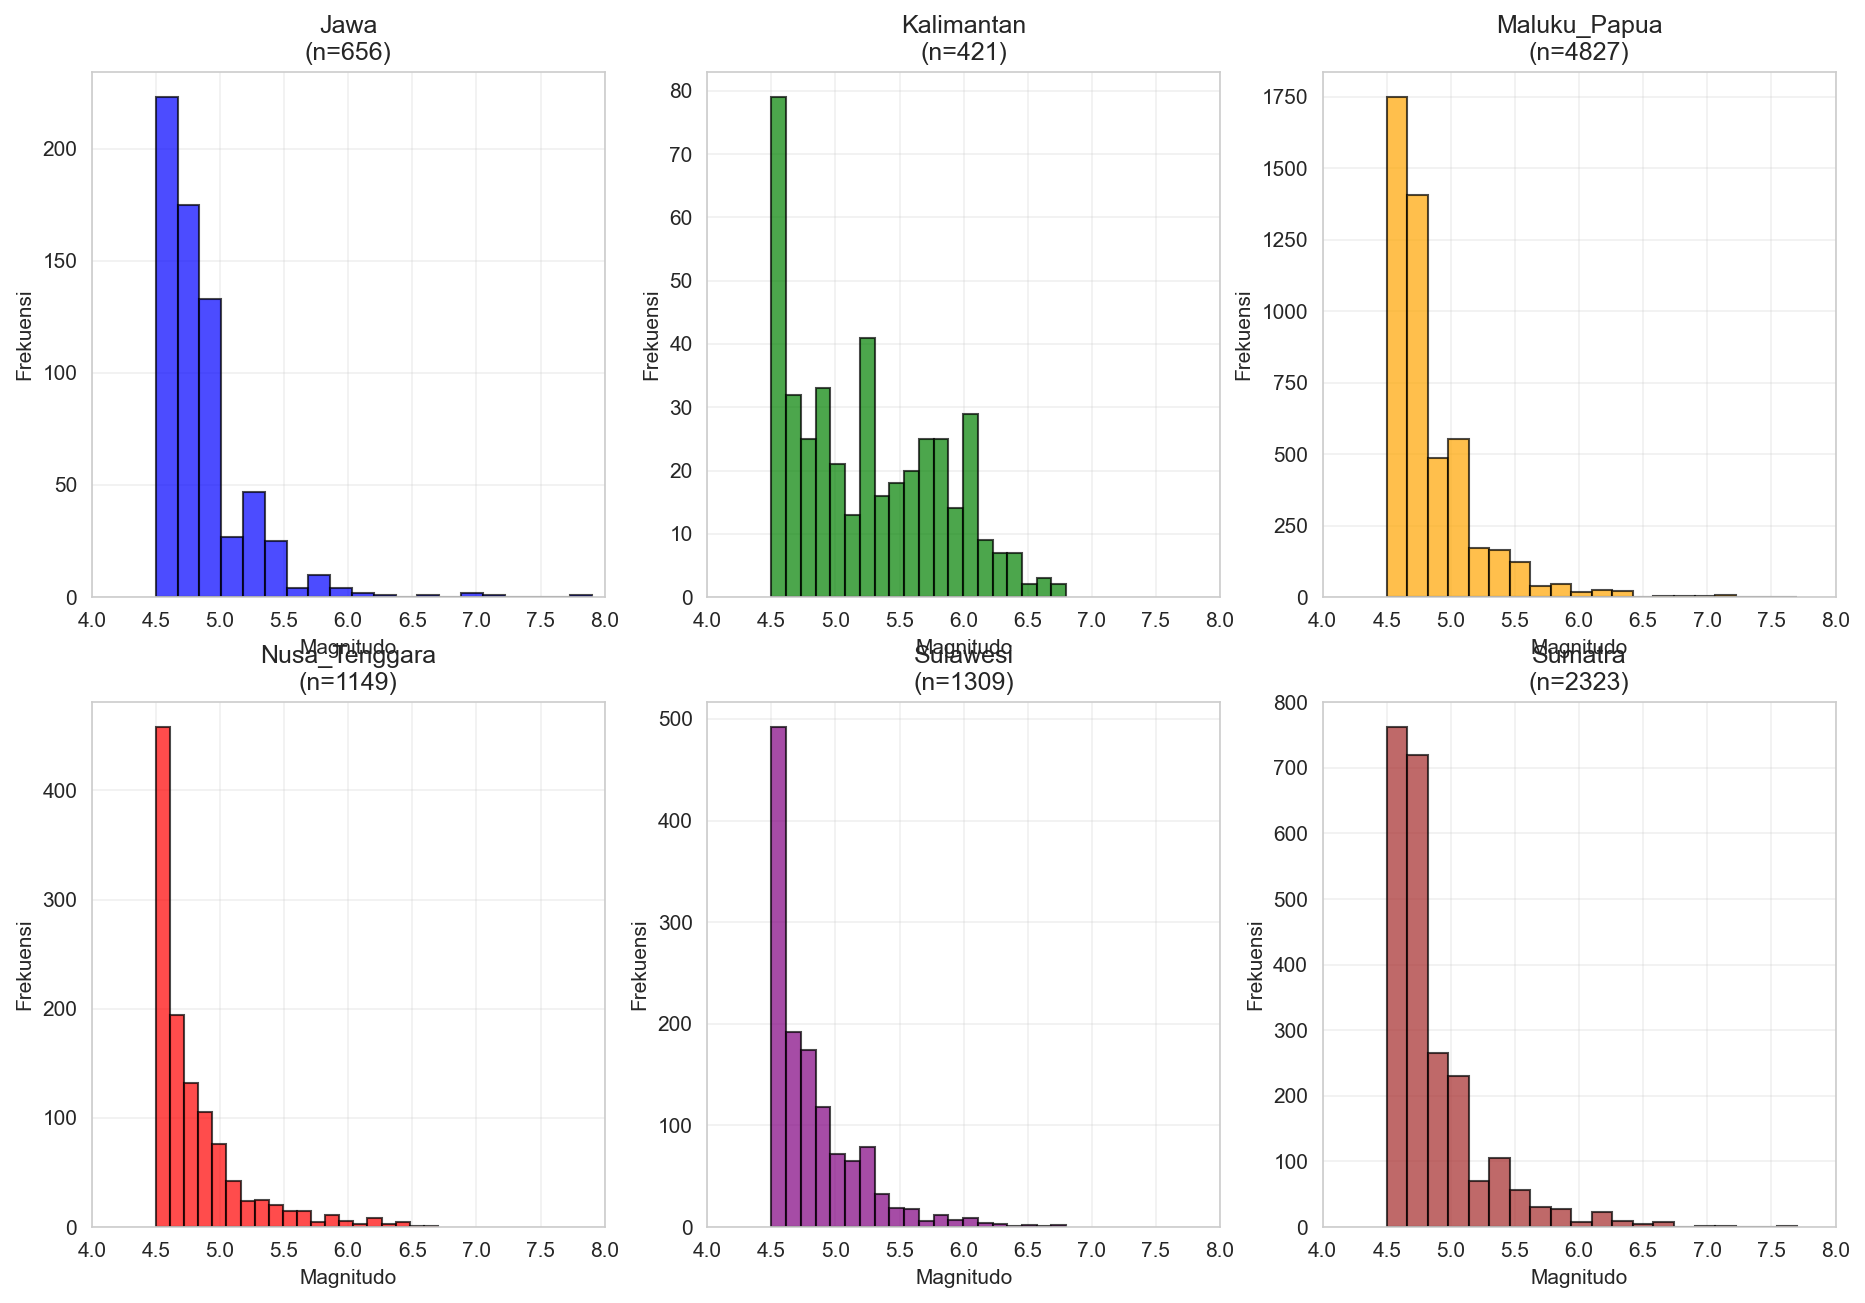

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VISUALISASI HISTOGRAM MAGNITUDO PER WILAYAH
Dari file filtered_events_selected.csv
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# =============================================
# 1. KONFIGURASI
# =============================================

CSV_PATH = "/Volumes/Extreme SSD/unduhan_juni_bmkg_usgs/hasilscan/eda_final_output/filtered_events_selected.csv"
OUTPUT_DIR = "visualisasi_wilayah"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# =============================================
# 2. FUNGSI KLASIFIKASI WILAYAH
# =============================================

def assign_region(lat, lon):
    """
    Klasifikasikan wilayah berdasarkan koordinat (lat, lon).
    """
    # Wilayah daratan utama Indonesia
    if 94 <= lon <= 106 and -6 <= lat <= 6:
        return "Sumatra"
    elif 106 <= lon <= 114 and -9 <= lat <= -5:
        return "Jawa"
    elif 108 <= lon <= 120 and -5 <= lat <= 6:
        return "Kalimantan"
    elif 114 <= lon <= 126 and -6 <= lat <= 2:
        return "Sulawesi"
    elif 114 <= lon <= 126 and -11 <= lat <= -5:
        return "Nusa_Tenggara"
    elif 126 <= lon <= 142 and -12 <= lat <= 2:
        return "Maluku_Papua"
    else:
        return "Laut"  # di luar daratan utama

# =============================================
# 3. BACA DATA
# =============================================

print("📂 Membaca file CSV...")
df = pd.read_csv(CSV_PATH)
print(f"✅ Total event: {len(df)}")
print(f"📊 Kolom: {df.columns.tolist()}")

# Tambahkan kolom wilayah
df['region'] = df.apply(lambda row: assign_region(row['Latitude'], row['Longitude']), axis=1)

print("\n📊 Distribusi event per wilayah:")
print(df['region'].value_counts())

# =============================================
# 4. VISUALISASI
# =============================================

# Atur gaya
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 150

# --- 4a. Histogram per Wilayah ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

regions = df['region'].unique()
regions = sorted([r for r in regions if r != "Laut"]) + (["Laut"] if "Laut" in regions else [])

colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown', 'gray']

for idx, region in enumerate(regions):
    ax = axes[idx]
    data = df[df['region'] == region]['mag']
    ax.hist(data, bins=20, color=colors[idx % len(colors)], alpha=0.7, edgecolor='black')
    ax.set_title(f'{region}\n(n={len(data)})', fontsize=12)
    ax.set_xlabel('Magnitudo', fontsize=10)
    ax.set_ylabel('Frekuensi', fontsize=10)
    ax.set_xlim([4.0, 8.0])
    ax.grid(True, alpha=0.3)

# Kosongkan axis jika kurang dari 7 region
for idx in range(len(regions), 6):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/histogram_magnitude_by_region.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"✅ Histogram per wilayah tersimpan di: {OUTPUT_DIR}/histogram_magnitude_by_region.png")

# --- 4b. Boxplot per Wilayah ---
fig, ax = plt.subplots(figsize=(12, 6))
data_by_region = [df[df['region'] == r]['mag'] for r in regions]
bp = ax.boxplot(data_by_region, labels=regions, patch_artist=True)

for patch, color in zip(bp['boxes'], colors[:len(regions)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Magnitudo', fontsize=12)
ax.set_title('Distribusi Magnitudo per Wilayah (Boxplot)', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([4.0, 8.0])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/boxplot_magnitude_by_region.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"✅ Boxplot tersimpan di: {OUTPUT_DIR}/boxplot_magnitude_by_region.png")

# --- 4c. Peta Sebaran Event dengan Warna Wilayah ---
fig, ax = plt.subplots(figsize=(12, 10))
colors_map = {'Sumatra': 'blue', 'Jawa': 'green', 'Kalimantan': 'orange',
              'Sulawesi': 'red', 'Nusa_Tenggara': 'purple', 
              'Maluku_Papua': 'brown', 'Laut': 'gray'}

for region, color in colors_map.items():
    subset = df[df['region'] == region]
    if len(subset) > 0:
        ax.scatter(subset['Longitude'], subset['Latitude'], 
                   c=color, s=2, alpha=0.6, label=f"{region} ({len(subset)})")

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Sebaran Event per Wilayah', fontsize=14)
ax.set_xlim(94, 142)
ax.set_ylim(-12, 8)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/spatial_distribution_by_region.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"✅ Peta sebaran tersimpan di: {OUTPUT_DIR}/spatial_distribution_by_region.png")

# --- 4d. Statistik Per Wilayah ---
stats = df.groupby('region')['mag'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
stats = stats.sort_values('count', ascending=False)
stats.to_csv(f"{OUTPUT_DIR}/stats_by_region.csv")
print(f"✅ Statistik per wilayah tersimpan di: {OUTPUT_DIR}/stats_by_region.csv")

print("\n📊 STATISTIK MAGNITUDO PER WILAYAH:")
print(stats.to_string())

# =============================================
# 5. RINGKASAN
# =============================================

print("\n" + "="*60)
print("📊 RINGKASAN VISUALISASI")
print("="*60)
print(f"Total event: {len(df)}")
for region in regions:
    count = len(df[df['region'] == region])
    mean_mag = df[df['region'] == region]['mag'].mean()
    print(f"{region:15} : {count:5} event, magnitudo rata-rata: {mean_mag:.2f}")
print("="*60)
print(f"\n✅ Semua visualisasi tersimpan di folder: {OUTPUT_DIR}/")

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ANALISIS STASIUN DARI FILE .mseed YANG TERUNDUH
Menampilkan distribusi stasiun dan jaringan.
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# =============================================
# 1. KONFIGURASI
# =============================================

# Direktori tempat file .mseed disimpan
OUTPUT_DIR = "/Volumes/Extreme SSD/unduhan_waveform_geofon"

# =============================================
# 2. BACA FILE .mseed
# =============================================

print("📂 Membaca file .mseed...")
files = list(Path(OUTPUT_DIR).glob("*.mseed"))
print(f"✅ Total file .mseed: {len(files)}")

# Ekstrak network dan station dari nama file
stations = []
networks = []
for f in files:
    parts = f.stem.split('_')
    if len(parts) >= 2:
        network = parts[0]
        station = parts[1]
        networks.append(network)
        stations.append(station)
    else:
        print(f"⚠️ Nama file tidak sesuai format: {f.name}")

# =============================================
# 3. STATISTIK STASIUN
# =============================================

print("\n📊 STATISTIK STASIUN:")
print(f"Total file: {len(files)}")
print(f"Total stasiun unik: {len(set(stations))}")
print(f"Total jaringan unik: {len(set(networks))}")

# Jumlah per stasiun
station_counts = Counter(stations)
print("\n🔍 10 Stasiun Terbanyak:")
for station, count in station_counts.most_common(10):
    print(f"   {station}: {count} file")

# Jumlah per jaringan
network_counts = Counter(networks)
print("\n🔍 Distribusi per Jaringan:")
for net, count in network_counts.most_common():
    print(f"   {net}: {count} file")

# =============================================
# 4. VISUALISASI
# =============================================

# --- 4a. Bar chart stasiun (top 20) ---
top_stations = station_counts.most_common(20)
df_station = pd.DataFrame(top_stations, columns=['Station', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=df_station, x='Station', y='Count', palette='viridis')
plt.title('20 Stasiun dengan File Terbanyak', fontsize=14)
plt.xlabel('Stasiun', fontsize=12)
plt.ylabel('Jumlah File', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('station_distribution_top20.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Grafik stasiun tersimpan: station_distribution_top20.png")

# --- 4b. Pie chart jaringan ---
plt.figure(figsize=(8, 8))
network_counts_df = pd.DataFrame(network_counts.items(), columns=['Network', 'Count'])
plt.pie(network_counts_df['Count'], labels=network_counts_df['Network'], autopct='%1.1f%%')
plt.title('Distribusi Jaringan Stasiun')
plt.tight_layout()
plt.savefig('network_distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Grafik jaringan tersimpan: network_distribution.png")

# =============================================
# 5. SIMPAN DATA KE CSV
# =============================================

df_station_all = pd.DataFrame({'Network': networks, 'Station': stations})
df_station_all.to_csv('station_list.csv', index=False)
print("✅ Daftar stasiun tersimpan: station_list.csv")

print("\n✨ Selesai!")

📂 Membaca file .mseed...
✅ Total file .mseed: 25880

📊 STATISTIK STASIUN:
Total file: 25880
Total stasiun unik: 31
Total jaringan unik: 3

🔍 10 Stasiun Terbanyak:
   GE: 12750 file
   TNTI: 2500 file
   MNAI: 1166 file
   SAUI: 834 file
   BNDI: 832 file
   GENI: 832 file
   FAKI: 756 file
   GSI: 741 file
   LUWI: 696 file
   PLAI: 569 file

🔍 Distribusi per Jaringan:
   .: 12940 file
   GE: 12750 file
   7G: 190 file
✅ Grafik stasiun tersimpan: station_distribution_top20.png
✅ Grafik jaringan tersimpan: network_distribution.png
✅ Daftar stasiun tersimpan: station_list.csv

✨ Selesai!


In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
EDA (Exploratory Data Analysis) untuk HYBRID EARTHQUAKE CATALOG
Tujuan: Memahami struktur, kualitas, dan distribusi data
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

CSV_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv"
OUTPUT_DIR = "eda_hybrid_catalog"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# =============================================
# 2. BACA DATA
# =============================================

print("="*70)
print("📂  MEMBACA HYBRID CATALOG")
print("="*70)

df = pd.read_csv(CSV_PATH)
print(f"✅  Jumlah baris: {len(df)}")
print(f"✅  Kolom: {df.columns.tolist()}")

# Konversi waktu
df['datetime'] = pd.to_datetime(df['time_utc'], utc=True)
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month

print(f"✅  Rentang waktu: {df['datetime'].min()} - {df['datetime'].max()}")
print(f"✅  Sumber data: {df['source'].unique().tolist()}")

# =============================================
# 3. STATISTIK DASAR
# =============================================

print("\n" + "="*70)
print("📊  STATISTIK MAGNITUDO & KEDALAMAN")
print("="*70)

print(f"\n📊 MAGNITUDO:")
print(f"   Min: {df['magnitude'].min():.1f}")
print(f"   Max: {df['magnitude'].max():.1f}")
print(f"   Mean: {df['magnitude'].mean():.2f}")
print(f"   Median: {df['magnitude'].median():.2f}")
print(f"   NaN: {df['magnitude'].isna().sum()}")

print(f"\n📊 KEDALAMAN:")
print(f"   Min: {df['depth_km'].min():.1f} km")
print(f"   Max: {df['depth_km'].max():.1f} km")
print(f"   Mean: {df['depth_km'].mean():.2f} km")
print(f"   Median: {df['depth_km'].median():.2f} km")
print(f"   NaN: {df['depth_km'].isna().sum()}")

# =============================================
# 4. DISTRIBUSI PER TAHUN
# =============================================

print("\n" + "="*70)
print("📈  DISTRIBUSI EVENT PER TAHUN")
print("="*70)

yearly = df['year'].value_counts().sort_index()
print(yearly)

plt.figure(figsize=(14, 5))
yearly.plot(kind='bar', color='steelblue')
plt.title('Jumlah Gempa per Tahun (Hybrid Catalog)', fontsize=14)
plt.xlabel('Tahun')
plt.ylabel('Jumlah Event')
plt.grid(True, alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/yearly_distribution.png", dpi=150, bbox_inches='tight')
plt.close()
print(f"📊  Grafik tersimpan di: {OUTPUT_DIR}/yearly_distribution.png")

# =============================================
# 5. HISTOGRAM MAGNITUDO
# =============================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram magnitudo
ax1.hist(df['magnitude'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax1.axvline(4.5, color='red', linestyle='--', linewidth=2, label='M≥4.5')
ax1.axvline(5.0, color='orange', linestyle='--', linewidth=2, label='M≥5.0')
ax1.set_xlabel('Magnitudo')
ax1.set_ylabel('Frekuensi')
ax1.set_title('Distribusi Magnitudo')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Histogram kedalaman
ax2.hist(df['depth_km'], bins=50, color='forestgreen', edgecolor='black', alpha=0.7)
ax2.axvline(100, color='red', linestyle='--', linewidth=2, label='Depth ≤ 100 km')
ax2.axvline(150, color='orange', linestyle='--', linewidth=2, label='Depth ≤ 150 km')
ax2.set_xlabel('Kedalaman (km)')
ax2.set_ylabel('Frekuensi')
ax2.set_title('Distribusi Kedalaman')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 300])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/magnitude_depth_histograms.png", dpi=150, bbox_inches='tight')
plt.close()
print(f"📊  Histogram tersimpan di: {OUTPUT_DIR}/magnitude_depth_histograms.png")

# =============================================
# 6. PETA SEBARAN
# =============================================

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    df['longitude'], df['latitude'],
    c=df['magnitude'], s=2, cmap='viridis', alpha=0.5,
    vmin=df['magnitude'].min(), vmax=df['magnitude'].max()
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Sebaran Gempa Hybrid Catalog (warna = magnitudo)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_xlim(90, 145)
ax.set_ylim(-12, 8)

cbar = plt.colorbar(scatter)
cbar.set_label('Magnitudo')

plt.savefig(f"{OUTPUT_DIR}/spatial_map.png", dpi=150, bbox_inches='tight')
plt.close()
print(f"🗺️  Peta tersimpan di: {OUTPUT_DIR}/spatial_map.png")

# =============================================
# 7. FILTER UNTUK MCU-QUAKE
# =============================================

print("\n" + "="*70)
print("🎯  FILTER UNTUK MCU-QUAKE (M≥4.5, Depth≤150km, 2010-2024)")
print("="*70)

filtered = df[
    (df['magnitude'] >= 4.5) &
    (df['depth_km'] <= 150) &
    (df['year'] >= 2010) &
    (df['year'] <= 2024)
]

print(f"✅  Total event lolos filter: {len(filtered)}")
print(f"   Rentang magnitudo: {filtered['magnitude'].min():.1f} - {filtered['magnitude'].max():.1f}")
print(f"   Rentang kedalaman: {filtered['depth_km'].min():.1f} - {filtered['depth_km'].max():.1f} km")

# Distribusi per tahun
if len(filtered) > 0:
    filtered_yearly = filtered['year'].value_counts().sort_index()
    print(f"\n   Distribusi per tahun:")
    for year, count in filtered_yearly.items():
        print(f"      {year}: {count}")

# =============================================
# 8. SIMPAN HASIL FILTER
# =============================================

if len(filtered) > 0:
    filtered_path = f"{OUTPUT_DIR}/filtered_hybrid_events.csv"
    filtered[['time_utc', 'latitude', 'longitude', 'depth_km', 'magnitude']].to_csv(filtered_path, index=False)
    print(f"\n💾  {len(filtered)} event tersimpan di: {filtered_path}")
else:
    print("\n⚠️  Tidak ada event yang lolos filter.")

# =============================================
# 9. STATISTIK BERDASARKAN SUMBER
# =============================================

print("\n" + "="*70)
print("📊  STATISTIK BERDASARKAN SUMBER DATA")
print("="*70)

source_stats = df.groupby('source').agg({
    'event_id': 'count',
    'magnitude': ['mean', 'min', 'max'],
    'depth_km': ['mean', 'min', 'max']
}).round(2)

print(source_stats)
source_stats.to_csv(f"{OUTPUT_DIR}/source_statistics.csv")

# =============================================
# 10. CEK DUPLIKAT
# =============================================

print("\n" + "="*70)
print("🔍  CEK DUPLIKAT")
print("="*70)

# Duplikat berdasarkan waktu + koordinat (toleransi 1 menit)
df['time_round'] = df['datetime'].dt.round('1min')
duplicates = df.duplicated(subset=['time_round', 'latitude', 'longitude'], keep=False)
dup_count = duplicates.sum()
print(f"✅  Jumlah duplikat (toleransi 1 menit, lokasi sama): {dup_count}")
if dup_count > 0:
    print("   Contoh duplikat:")
    print(df[duplicates][['datetime', 'latitude', 'longitude', 'magnitude', 'source']].head())

# =============================================
# 11. RINGKASAN
# =============================================

print("\n" + "="*70)
print("✨  EDA SELESAI!")
print("="*70)
print(f"📁  Output folder: {OUTPUT_DIR}/")

📂  MEMBACA HYBRID CATALOG
✅  Jumlah baris: 232301
✅  Kolom: ['event_id', 'time_utc', 'latitude', 'longitude', 'magnitude', 'depth_km', 'source']
✅  Rentang waktu: 2001-01-01 12:44:31+00:00 - 2024-12-31 23:58:59+00:00
✅  Sumber data: ['USGS', 'BMKG']

📊  STATISTIK MAGNITUDO & KEDALAMAN

📊 MAGNITUDO:
   Min: 0.2
   Max: 9.1
   Mean: 3.25
   Median: 3.10
   NaN: 0

📊 KEDALAMAN:
   Min: 0.8 km
   Max: 750.0 km
   Mean: 44.82 km
   Median: 15.00 km
   NaN: 0

📈  DISTRIBUSI EVENT PER TAHUN
year
2001     1110
2002     1422
2003     1321
2004     2249
2005     4028
2006     2882
2007     2967
2008     2471
2009     4189
2010     6516
2011     5052
2012     7313
2013     4804
2014     5747
2015     6263
2016     7688
2017    10138
2018     9125
2019    20948
2020    21361
2021    11911
2022    29303
2023    27493
2024    36000
Name: count, dtype: int64
📊  Grafik tersimpan di: eda_hybrid_catalog/yearly_distribution.png
📊  Histogram tersimpan di: eda_hybrid_catalog/magnitude_depth_histograms.png


In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ANALISIS STASIUN DARI FILE .mseed YANG TERUNDUH
Menampilkan daftar stasiun, jaringan, dan distribusinya.
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from pathlib import Path

# =============================================
# 1. KONFIGURASI
# =============================================

WAVEFORM_DIR = "/Volumes/Extreme SSD/unduhan_waveform_geofon"

# =============================================
# 2. BACA FILE .mseed
# =============================================

print("📂 Membaca file .mseed...")
files = list(Path(WAVEFORM_DIR).glob("*.mseed"))
print(f"✅ Total file .mseed: {len(files)}")

# Ekstrak network dan station dari nama file
stations = []
networks = []
full_names = []

for f in files:
    parts = f.stem.split('_')
    if len(parts) >= 2:
        network = parts[0]
        station = parts[1]
        networks.append(network)
        stations.append(station)
        full_names.append(f"{network}_{station}")
    else:
        print(f"⚠️ Nama file tidak sesuai format: {f.name}")

# =============================================
# 3. STATISTIK
# =============================================

print("\n📊 STATISTIK STASIUN:")
print(f"Total file: {len(files)}")
print(f"Total stasiun unik: {len(set(stations))}")
print(f"Total jaringan unik: {len(set(networks))}")

# Jumlah per stasiun
station_counts = Counter(stations)
print("\n🔍 10 Stasiun Terbanyak:")
for station, count in station_counts.most_common(10):
    print(f"   {station}: {count} file")

# Jumlah per jaringan
network_counts = Counter(networks)
print("\n🔍 Distribusi per Jaringan:")
for net, count in network_counts.most_common():
    print(f"   {net}: {count} file ({count/len(files)*100:.1f}%)")

# =============================================
# 4. VISUALISASI
# =============================================

# --- 4a. Bar chart stasiun (top 20) ---
top_stations = station_counts.most_common(20)
df_station = pd.DataFrame(top_stations, columns=['Station', 'Count'])

plt.figure(figsize=(14, 6))
sns.barplot(data=df_station, x='Station', y='Count', palette='viridis')
plt.title('20 Stasiun dengan File Terbanyak', fontsize=14)
plt.xlabel('Stasiun', fontsize=12)
plt.ylabel('Jumlah File', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('station_distribution_top20.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Grafik stasiun tersimpan: station_distribution_top20.png")

# --- 4b. Pie chart jaringan ---
plt.figure(figsize=(8, 8))
network_counts_df = pd.DataFrame(network_counts.items(), columns=['Network', 'Count'])
plt.pie(network_counts_df['Count'], labels=network_counts_df['Network'], autopct='%1.1f%%')
plt.title('Distribusi Jaringan Stasiun')
plt.tight_layout()
plt.savefig('network_distribution.png', dpi=300, bbox_inches='tight')
plt.close()
print("✅ Grafik jaringan tersimpan: network_distribution.png")

# =============================================
# 5. SIMPAN DATA KE CSV
# =============================================

df_station_all = pd.DataFrame({'Network': networks, 'Station': stations})
df_station_all.to_csv('station_list.csv', index=False)
print("✅ Daftar stasiun tersimpan: station_list.csv")

# =============================================
# 6. TAMPILAN RINGKAS
# =============================================

print("\n📋 DAFTAR SEMUA STASIUN:")
for station in sorted(set(stations)):
    count = station_counts[station]
    print(f"   {station}: {count}")

print("\n✨ Selesai!")

📂 Membaca file .mseed...
✅ Total file .mseed: 25880

📊 STATISTIK STASIUN:
Total file: 25880
Total stasiun unik: 31
Total jaringan unik: 3

🔍 10 Stasiun Terbanyak:
   GE: 12750 file
   TNTI: 2500 file
   MNAI: 1166 file
   SAUI: 834 file
   BNDI: 832 file
   GENI: 832 file
   FAKI: 756 file
   GSI: 741 file
   LUWI: 696 file
   PLAI: 569 file

🔍 Distribusi per Jaringan:
   .: 12940 file (50.0%)
   GE: 12750 file (49.3%)
   7G: 190 file (0.7%)
✅ Grafik stasiun tersimpan: station_distribution_top20.png
✅ Grafik jaringan tersimpan: network_distribution.png
✅ Daftar stasiun tersimpan: station_list.csv

📋 DAFTAR SEMUA STASIUN:
   7G: 190
   BB02: 120
   BB05: 38
   BBJI: 455
   BKB: 217
   BKNI: 271
   BNDI: 832
   CISI: 300
   FAKI: 756
   GE: 12750
   GENI: 832
   GSI: 741
   JAGI: 496
   LHMI: 281
   LUWI: 696
   MMRI: 261
   MNAI: 1166
   PLAI: 569
   PMBI: 109
   PMG: 2
   SANI: 422
   SAUI: 834
   SMRI: 93
   SOEI: 289
   SP09: 20
   SP12: 2
   SP28: 10
   TNTI: 2500
   TOLI: 59
   TOL

In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
INVESTIGASI TAHUN 2004 PADA HYBRID CATALOG
Menampilkan statistik, distribusi, dan event-event besar.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

CSV_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv"
OUTPUT_DIR = "investigasi_2004"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# =============================================
# 2. BACA DATA
# =============================================

print("="*70)
print("🔍  INVESTIGASI TAHUN 2004")
print("="*70)

df = pd.read_csv(CSV_PATH)
df['datetime'] = pd.to_datetime(df['time_utc'], utc=True)
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

print(f"✅ Total event dalam katalog: {len(df)}")
print(f"✅ Rentang tahun: {df['year'].min()} - {df['year'].max()}")

# =============================================
# 3. DATA TAHUN 2004
# =============================================

df_2004 = df[df['year'] == 2004]
print(f"\n📊 TAHUN 2004:")
print(f"   Total event: {len(df_2004)}")
print(f"   Rentang magnitudo: {df_2004['magnitude'].min():.1f} - {df_2004['magnitude'].max():.1f}")
print(f"   Rentang kedalaman: {df_2004['depth_km'].min():.1f} - {df_2004['depth_km'].max():.1f} km")

# Sumber data
print(f"\n   Sumber data:")
for source, count in df_2004['source'].value_counts().items():
    print(f"      {source}: {count} ({count/len(df_2004)*100:.1f}%)")

# =============================================
# 4. EVENT BESAR DI TAHUN 2004
# =============================================

print(f"\n🔍 EVENT BESAR DI TAHUN 2004 (M ≥ 6.0):")
large_events = df_2004[df_2004['magnitude'] >= 6.0].sort_values('magnitude', ascending=False)
if len(large_events) > 0:
    print(large_events[['datetime', 'latitude', 'longitude', 'magnitude', 'depth_km', 'source']].to_string(index=False))
else:
    print("   Tidak ada event M≥6.0")

# =============================================
# 5. GEMPA 26 DESEMBER 2004
# =============================================

print(f"\n🔍 GEMPA 26 DESEMBER 2004 (ACEH):")
# Cari event pada 26 Desember 2004
dec26 = df_2004[(df_2004['month'] == 12) & (df_2004['day'] == 26)]
if len(dec26) > 0:
    print(dec26[['datetime', 'latitude', 'longitude', 'magnitude', 'depth_km', 'source']].to_string(index=False))
else:
    print("   Tidak ada event pada 26 Desember 2004.")

# Cari event dengan magnitudo terbesar di sekitar Aceh (lat 3-6, lon 94-97)
aceh = df_2004[(df_2004['latitude'] >= 2) & (df_2004['latitude'] <= 7) &
               (df_2004['longitude'] >= 93) & (df_2004['longitude'] <= 98)]
if len(aceh) > 0:
    print(f"\n   Event di wilayah Aceh (lat 2-7, lon 93-98): {len(aceh)} event")
    print(aceh[['datetime', 'latitude', 'longitude', 'magnitude', 'depth_km', 'source']].head(10).to_string(index=False))

# =============================================
# 6. KOMPARASI DENGAN TAHUN LAIN
# =============================================

print(f"\n📊 KOMPARASI DENGAN TAHUN LAIN:")
yearly_counts = df['year'].value_counts().sort_index()
print(yearly_counts)

# Tampilkan 2004 dalam konteks
print(f"\n   Tahun 2004: {yearly_counts.get(2004, 0)} event")
print(f"   Rata-rata event per tahun (2001-2024): {yearly_counts.mean():.0f}")
print(f"   Tahun dengan event terbanyak: {yearly_counts.idxmax()} ({yearly_counts.max()} event)")
print(f"   Tahun dengan event tersedikit: {yearly_counts.idxmin()} ({yearly_counts.min()} event)")

# =============================================
# 7. VISUALISASI
# =============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 7a. Perbandingan jumlah event per tahun
ax1 = axes[0, 0]
yearly_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.axvline(2004 - 2001, color='red', linestyle='--', linewidth=2, label='Tahun 2004')
ax1.set_xlabel('Tahun')
ax1.set_ylabel('Jumlah Event')
ax1.set_title('Jumlah Event per Tahun')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 7b. Histogram magnitudo 2004 vs lainnya
ax2 = axes[0, 1]
other_years = df[df['year'] != 2004]
ax2.hist(other_years['magnitude'], bins=30, alpha=0.5, label='Lainnya (2001-2024)', color='blue')
ax2.hist(df_2004['magnitude'], bins=30, alpha=0.7, label='2004', color='red')
ax2.set_xlabel('Magnitudo')
ax2.set_ylabel('Frekuensi')
ax2.set_title('Distribusi Magnitudo: 2004 vs Lainnya')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 7c. Peta sebaran 2004
ax3 = axes[1, 0]
if len(df_2004) > 0:
    scatter = ax3.scatter(df_2004['longitude'], df_2004['latitude'],
                          c=df_2004['magnitude'], s=10, cmap='viridis', alpha=0.7)
    ax3.set_xlabel('Longitude')
    ax3.set_ylabel('Latitude')
    ax3.set_title('Sebaran Event 2004 (warna = magnitudo)')
    ax3.set_xlim(90, 145)
    ax3.set_ylim(-12, 8)
    ax3.grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=ax3)
    cbar.set_label('Magnitudo')

# 7d. Perbandingan kedalaman 2004 vs lainnya
ax4 = axes[1, 1]
ax4.hist(other_years['depth_km'], bins=30, alpha=0.5, label='Lainnya (2001-2024)', color='blue')
ax4.hist(df_2004['depth_km'], bins=30, alpha=0.7, label='2004', color='red')
ax4.set_xlabel('Kedalaman (km)')
ax4.set_ylabel('Frekuensi')
ax4.set_title('Distribusi Kedalaman: 2004 vs Lainnya')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim([0, 200])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/2004_comparison.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"📊  Grafik tersimpan di: {OUTPUT_DIR}/2004_comparison.png")

# =============================================
# 8. SIMPAN DATA 2004
# =============================================

if len(df_2004) > 0:
    df_2004.to_csv(f"{OUTPUT_DIR}/events_2004.csv", index=False)
    print(f"💾  Data 2004 tersimpan di: {OUTPUT_DIR}/events_2004.csv")

# =============================================
# 9. RINGKASAN
# =============================================

print("\n" + "="*70)
print("📊  RINGKASAN INVESTIGASI 2004")
print("="*70)

print(f"Total event 2004: {len(df_2004)}")
if len(df_2004) > 0:
    print(f"Magnitudo terbesar: {df_2004['magnitude'].max():.1f}")
    print(f"Magnitudo terkecil: {df_2004['magnitude'].min():.1f}")
    print(f"Kedalaman rata-rata: {df_2004['depth_km'].mean():.1f} km")
    print(f"Sumber data dominan: {df_2004['source'].value_counts().index[0]} ({df_2004['source'].value_counts().iloc[0]} event)")
else:
    print("Tidak ada event di tahun 2004!")

print("\n💡  KESIMPULAN:")
if len(df_2004) == 0:
    print("   ❌ Katalog tidak memiliki data tahun 2004 sama sekali.")
    print("   → Kemungkinan data 2004 sengaja dihilangkan karena kualitas rendah.")
elif len(df_2004) < 1000:
    print(f"   ⚠️  Hanya {len(df_2004)} event di tahun 2004.")
    print("   → Kemungkinan data 2004 tidak lengkap atau banyak yang hilang.")
else:
    print(f"   ✅ Ada {len(df_2004)} event di tahun 2004.")
    print("   → Data 2004 cukup lengkap.")
print("="*70)

🔍  INVESTIGASI TAHUN 2004
✅ Total event dalam katalog: 232301
✅ Rentang tahun: 2001 - 2024

📊 TAHUN 2004:
   Total event: 2249
   Rentang magnitudo: 3.3 - 9.1
   Rentang kedalaman: 2.0 - 641.5 km

   Sumber data:
      USGS: 2249 (100.0%)

🔍 EVENT BESAR DI TAHUN 2004 (M ≥ 6.0):
                 datetime  latitude  longitude  magnitude  depth_km source
2004-12-26 00:58:53+00:00     3.295     95.982        9.1      30.0   USGS
2004-11-11 21:26:41+00:00    -8.152    124.868        7.5      10.0   USGS
2004-07-25 14:35:19+00:00    -2.427    103.981        7.3     582.1   USGS
2004-02-07 02:42:35+00:00    -4.003    135.023        7.3      10.0   USGS
2004-11-26 02:25:03+00:00    -3.609    135.404        7.1      10.0   USGS
2004-02-05 21:05:02+00:00    -3.615    135.538        7.0      16.6   USGS
2004-04-23 01:50:30+00:00    -9.362    122.839        6.7      65.8   USGS
2004-01-28 22:15:30+00:00    -3.120    127.400        6.7      17.4   USGS
2004-02-08 08:58:51+00:00    -3.665    135.339

In [12]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
INVESTIGASI GEMPA-GEMPA TERDAHSYAT DI INDONESIA
Mencocokkan katalog hybrid dengan daftar gempa besar yang diketahui.
FIX: timezone-aware comparison.
"""

import pandas as pd
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

CSV_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv"

# Daftar gempa besar Indonesia (sumber: BMKG, USGS, literatur)
MAJOR_EARTHQUAKES = [
    (2004, 12, 26, 9.1, "Aceh", "Gempa & Tsunami Aceh 2004"),
    (2005, 3, 28, 8.6, "Nias", "Gempa Nias 2005"),
    (2006, 5, 27, 6.3, "Yogyakarta", "Gempa Yogyakarta 2006"),
    (2006, 7, 17, 7.7, "Pangandaran", "Gempa & Tsunami Pangandaran 2006"),
    (2007, 9, 12, 8.5, "Bengkulu", "Gempa Bengkulu 2007"),
    (2009, 9, 30, 7.6, "Padang", "Gempa Padang 2009"),
    (2010, 4, 6, 7.7, "Sumatra", "Gempa Sumatra 2010"),
    (2010, 10, 25, 7.7, "Mentawai", "Gempa & Tsunami Mentawai 2010"),
    (2012, 4, 11, 8.6, "Aceh", "Gempa Aceh 2012 (aftershock)"),
    (2013, 4, 6, 7.2, "Papua", "Gempa Papua 2013"),
    (2016, 12, 7, 6.5, "Aceh", "Gempa Pidie Jaya 2016"),
    (2018, 8, 5, 7.0, "Lombok", "Gempa Lombok 2018"),
    (2018, 9, 28, 7.5, "Palu", "Gempa & Tsunami Palu 2018"),
    (2019, 7, 14, 7.3, "Maluku", "Gempa Maluku 2019"),
    (2021, 1, 14, 7.0, "Sulawesi", "Gempa Sulawesi 2021 (Mamuju)"),
    (2022, 11, 21, 5.6, "Cianjur", "Gempa Cianjur 2022"),
    (2023, 1, 18, 7.2, "Maluku", "Gempa Maluku 2023"),
]

# =============================================
# 2. BACA DATA
# =============================================

print("="*70)
print("🔍  INVESTIGASI GEMPA TERDAHSYAT")
print("="*70)

df = pd.read_csv(CSV_PATH)
df['datetime'] = pd.to_datetime(df['time_utc'], utc=True)
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

print(f"✅ Total event: {len(df)}")
print(f"✅ Rentang tahun: {df['year'].min()} - {df['year'].max()}")

# =============================================
# 3. SEMUA EVENT DENGAN MAGNITUDO ≥ 7.0
# =============================================

print("\n" + "="*70)
print("📊  EVENT DENGAN MAGNITUDO ≥ 7.0")
print("="*70)

df_7 = df[df['magnitude'] >= 7.0].sort_values('magnitude', ascending=False)
print(f"Jumlah event M≥7.0: {len(df_7)}")
if len(df_7) > 0:
    print(df_7[['datetime', 'latitude', 'longitude', 'magnitude', 'depth_km', 'source']].to_string(index=False))
else:
    print("Tidak ada event M≥7.0!")

# =============================================
# 4. COCOKKAN DENGAN DAFTAR GEMPA BESAR
# =============================================

print("\n" + "="*70)
print("🎯  PENCARIAN GEMPA BESAR BERDASARKAN TANGGAL")
print("="*70)

results = []
for year, month, day, expected_mag, location, desc in MAJOR_EARTHQUAKES:
    # Buat Timestamp dengan timezone UTC
    start = pd.Timestamp(year, month, day, 0, 0, 0, tz='UTC') - pd.Timedelta(days=2)
    end = pd.Timestamp(year, month, day, 23, 59, 59, tz='UTC') + pd.Timedelta(days=2)
    
    mask = (df['datetime'] >= start) & (df['datetime'] <= end)
    candidates = df[mask].sort_values('magnitude', ascending=False)
    
    if len(candidates) > 0:
        best = candidates.iloc[0]
        found_mag = best['magnitude']
        found_date = best['datetime']
        found_source = best['source']
        lat = best['latitude']
        lon = best['longitude']
        
        # Cek apakah magnitudo mendekati yang diharapkan (toleransi 1.0)
        match = abs(found_mag - expected_mag) < 1.0
        
        results.append({
            'Gempa': desc,
            'Tanggal': f"{year}-{month:02d}-{day:02d}",
            'Ditemukan': '✅' if match else '⚠️',
            'Tgl Ditemukan': found_date.strftime('%Y-%m-%d %H:%M'),
            'Mag Katalog': found_mag,
            'Mag Diharapkan': expected_mag,
            'Selisih': found_mag - expected_mag,
            'Source': found_source,
            'Lat': lat,
            'Lon': lon
        })
    else:
        results.append({
            'Gempa': desc,
            'Tanggal': f"{year}-{month:02d}-{day:02d}",
            'Ditemukan': '❌',
            'Tgl Ditemukan': '-',
            'Mag Katalog': '-',
            'Mag Diharapkan': expected_mag,
            'Selisih': '-',
            'Source': '-',
            'Lat': '-',
            'Lon': '-'
        })

# Tampilkan hasil
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# =============================================
# 5. SIMPAN HASIL
# =============================================

# Simpan event M≥7.0
if len(df_7) > 0:
    df_7.to_csv("major_events_M7.csv", index=False)
    print("\n✅ Event M≥7.0 tersimpan di: major_events_M7.csv")

# Simpan hasil pencocokan
df_results.to_csv("major_earthquakes_check.csv", index=False)
print("✅ Hasil pencocokan tersimpan di: major_earthquakes_check.csv")

# =============================================
# 6. RINGKASAN
# =============================================

print("\n" + "="*70)
print("📊  RINGKASAN")
print("="*70)

total_major = len(results)
found = len(df_results[df_results['Ditemukan'] == '✅'])
partial = len(df_results[df_results['Ditemukan'] == '⚠️'])
not_found = len(df_results[df_results['Ditemukan'] == '❌'])

print(f"Total gempa besar yang dicari: {total_major}")
print(f"✅ Ditemukan dengan magnitudo sesuai: {found}")
print(f"⚠️ Ditemukan tetapi magnitudo berbeda: {partial}")
print(f"❌ Tidak ditemukan: {not_found}")

print("\n💡  KESIMPULAN:")
if not_found > 0:
    print(f"   ❌ Ada {not_found} gempa besar yang TIDAK tercatat di katalog.")
    print("   → Kemungkinan data hilang karena keterbatasan jaringan BMKG/USGS pada masa itu.")
else:
    print("   ✅ Semua gempa besar tercatat di katalog.")
print("="*70)

🔍  INVESTIGASI GEMPA TERDAHSYAT
✅ Total event: 232301
✅ Rentang tahun: 2001 - 2024

📊  EVENT DENGAN MAGNITUDO ≥ 7.0
Jumlah event M≥7.0: 59
                 datetime  latitude  longitude  magnitude  depth_km source
2004-12-26 00:58:53+00:00     3.295     95.982        9.1      30.0   USGS
2005-03-28 16:09:36+00:00     2.085     97.108        8.6      30.0   USGS
2007-09-12 11:10:26+00:00    -4.438    101.367        8.4      34.0   USGS
2020-07-06 22:56:24+00:00    -6.650    110.190        7.9      10.0   BMKG
2007-09-12 23:49:03+00:00    -2.625    100.841        7.9      35.0   USGS
2009-01-03 19:43:55+00:00    -0.540    132.890        7.9      17.0   BMKG
2023-01-09 17:47:34+00:00    -7.350    130.180        7.7     121.0   BMKG
2010-04-06 22:15:03+00:00     2.240     97.110        7.7      29.0   BMKG
2006-07-17 08:19:26+00:00    -9.284    107.419        7.7      20.0   USGS
2009-09-30 10:16:10+00:00    -0.800     99.880        7.7      81.0   BMKG
2023-11-08 04:53:55+00:00    -6.280 

In [13]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
DETEKSI DUPLIKAT ANTARA SUMBER BMKG DAN USGS
Mencari event yang sama yang tercatat dari dua sumber berbeda.
"""

import pandas as pd
import numpy as np
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

CSV_PATH = "/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv"

# Toleransi deteksi duplikat
TIME_TOLERANCE_SEC = 5    # selisih waktu maksimal 5 detik
LAT_TOLERANCE = 0.5       # selisih latitude maksimal 0.5 derajat (~55 km)
LON_TOLERANCE = 0.5       # selisih longitude maksimal 0.5 derajat (~55 km)
MAG_TOLERANCE = 0.5       # selisih magnitudo maksimal 0.5

# =============================================
# 2. BACA DATA
# =============================================

print("="*70)
print("🔍  DETEKSI DUPLIKAT BMKG vs USGS")
print("="*70)

df = pd.read_csv(CSV_PATH)
df['datetime'] = pd.to_datetime(df['time_utc'], utc=True)

print(f"✅ Total event: {len(df)}")
print(f"✅ Sumber data: {df['source'].unique().tolist()}")

# Pisahkan berdasarkan sumber
df_bmkg = df[df['source'] == 'BMKG'].copy()
df_usgs = df[df['source'] == 'USGS'].copy()
df_other = df[~df['source'].isin(['BMKG', 'USGS'])].copy()

print(f"\n📊 Distribusi sumber:")
print(f"   BMKG: {len(df_bmkg)} event")
print(f"   USGS: {len(df_usgs)} event")
print(f"   Lainnya: {len(df_other)} event")

# =============================================
# 3. DETEKSI DUPLIKAT
# =============================================

print("\n" + "="*70)
print("🔍  MENCARI DUPLIKAT (BMKG vs USGS)")
print("="*70)

duplicates = []

# Konversi ke numpy untuk mempercepat
bmkg_times = df_bmkg['datetime'].values
bmkg_lats = df_bmkg['latitude'].values
bmkg_lons = df_bmkg['longitude'].values
bmkg_mags = df_bmkg['magnitude'].values
bmkg_idx = df_bmkg.index.values

usgs_times = df_usgs['datetime'].values
usgs_lats = df_usgs['latitude'].values
usgs_lons = df_usgs['longitude'].values
usgs_mags = df_usgs['magnitude'].values
usgs_idx = df_usgs.index.values

print(f"🔍 Memeriksa {len(df_bmkg)} event BMKG terhadap {len(df_usgs)} event USGS...")

# Untuk setiap event BMKG, cari USGS terdekat
for i, (t_bmkg, lat_bmkg, lon_bmkg, mag_bmkg) in enumerate(
    zip(bmkg_times, bmkg_lats, bmkg_lons, bmkg_mags)
):
    # Cari event USGS dengan waktu dekat
    time_diff = np.abs((usgs_times - t_bmkg).astype('timedelta64[s]').astype(float))
    mask_time = time_diff <= TIME_TOLERANCE_SEC
    
    if not np.any(mask_time):
        continue
    
    # Dari yang waktu dekat, cari yang lokasi dekat
    candidates = np.where(mask_time)[0]
    
    for j in candidates:
        lat_diff = abs(usgs_lats[j] - lat_bmkg)
        lon_diff = abs(usgs_lons[j] - lon_bmkg)
        mag_diff = abs(usgs_mags[j] - mag_bmkg)
        
        if (lat_diff <= LAT_TOLERANCE and 
            lon_diff <= LON_TOLERANCE and 
            mag_diff <= MAG_TOLERANCE):
            
            duplicates.append({
                'bmkg_idx': bmkg_idx[i],
                'bmkg_time': t_bmkg,
                'bmkg_lat': lat_bmkg,
                'bmkg_lon': lon_bmkg,
                'bmkg_mag': mag_bmkg,
                'usgs_idx': usgs_idx[j],
                'usgs_time': usgs_times[j],
                'usgs_lat': usgs_lats[j],
                'usgs_lon': usgs_lons[j],
                'usgs_mag': usgs_mags[j],
                'time_diff': abs((usgs_times[j] - t_bmkg).total_seconds()),
                'lat_diff': lat_diff,
                'lon_diff': lon_diff,
                'mag_diff': mag_diff
            })
            break  # ambil satu USGS terbaik

print(f"✅ Ditemukan {len(duplicates)} pasangan duplikat.")

# =============================================
# 4. TAMPILKAN DUPLIKAT
# =============================================

if len(duplicates) > 0:
    df_dups = pd.DataFrame(duplicates)
    
    # Tampilkan 20 pertama
    print("\n📋 20 DUPLIKAT PERTAMA:")
    print(df_dups[['bmkg_time', 'bmkg_mag', 'usgs_time', 'usgs_mag', 
                   'time_diff', 'lat_diff', 'lon_diff']].head(20).to_string(index=False))
    
    # Statistik duplikat
    print("\n📊 STATISTIK DUPLIKAT:")
    print(f"   Rata-rata selisih waktu: {df_dups['time_diff'].mean():.2f} detik")
    print(f"   Rata-rata selisih magnitudo: {df_dups['mag_diff'].mean():.2f}")
    print(f"   Rata-rata selisih latitude: {df_dups['lat_diff'].mean():.4f}°")
    print(f"   Rata-rata selisih longitude: {df_dups['lon_diff'].mean():.4f}°")
    
    # =============================================
    # 5. SIMPAN HASIL
    # =============================================
    
    df_dups.to_csv("duplicates_bmkg_usgs.csv", index=False)
    print("\n✅ Daftar duplikat tersimpan di: duplicates_bmkg_usgs.csv")
    
    # =============================================
    # 6. REKOMENDASI PEMBERSIHAN
    # =============================================
    
    print("\n" + "="*70)
    print("💡  REKOMENDASI PEMBERSIHAN")
    print("="*70)
    
    # Ambil indeks duplikat
    dup_bmkg_idx = df_dups['bmkg_idx'].tolist()
    dup_usgs_idx = df_dups['usgs_idx'].tolist()
    
    # Buat dataset bersih (tanpa duplikat)
    # Strategi: pilih USGS jika magnitudo lebih akurat, atau pilih BMKG jika lebih lokal
    # Untuk sederhana, kita pilih BMKG jika magnitudo >= USGS, else USGS
    keep_idx = []
    for _, row in df_dups.iterrows():
        if row['bmkg_mag'] >= row['usgs_mag']:
            keep_idx.append(row['bmkg_idx'])
        else:
            keep_idx.append(row['usgs_idx'])
    
    # Buat daftar indeks yang akan dihapus
    remove_idx = list(set(dup_bmkg_idx + dup_usgs_idx) - set(keep_idx))
    
    # Buat dataset bersih
    df_clean = df.drop(index=remove_idx).copy()
    
    print(f"   Total duplikat yang akan dihapus: {len(remove_idx)}")
    print(f"   Total event setelah pembersihan: {len(df_clean)}")
    print(f"   (dari {len(df)} event awal)")
    
    # Simpan dataset bersih
    df_clean.to_csv("hybrid_catalog_clean.csv", index=False)
    print("\n✅ Dataset bersih tersimpan di: hybrid_catalog_clean.csv")
    
else:
    print("\n✅ Tidak ada duplikat yang terdeteksi antara BMKG dan USGS.")

# =============================================
# 7. RINGKASAN
# =============================================

print("\n" + "="*70)
print("📊  RINGKASAN")
print("="*70)
print(f"Total event katalog: {len(df)}")
print(f"  - BMKG: {len(df_bmkg)}")
print(f"  - USGS: {len(df_usgs)}")
print(f"  - Lainnya: {len(df_other)}")
if len(duplicates) > 0:
    print(f"Duplikat terdeteksi: {len(duplicates)} pasangan")
    print(f"Event yang akan dihapus: {len(remove_idx)}")
    print(f"Event setelah bersih: {len(df_clean)}")
else:
    print("Duplikat: Tidak ada")
print("="*70)

🔍  DETEKSI DUPLIKAT BMKG vs USGS
✅ Total event: 232301
✅ Sumber data: ['USGS', 'BMKG']

📊 Distribusi sumber:
   BMKG: 213851 event
   USGS: 18450 event
   Lainnya: 0 event

🔍  MENCARI DUPLIKAT (BMKG vs USGS)
🔍 Memeriksa 213851 event BMKG terhadap 18450 event USGS...
✅ Ditemukan 0 pasangan duplikat.

✅ Tidak ada duplikat yang terdeteksi antara BMKG dan USGS.

📊  RINGKASAN
Total event katalog: 232301
  - BMKG: 213851
  - USGS: 18450
  - Lainnya: 0
Duplikat: Tidak ada


In [16]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
INVESTIGASI HASIL UNDUHAN GEMPA MERUSAK
Memeriksa file yang berhasil diunduh, stasiun, dan kualitas data.
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from obspy import read
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

DOWNLOAD_DIR = "/Volumes/Extreme SSD/unduhan_waveform_major_earthquakes"
OUTPUT_DIR = "investigasi_major_download"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# =============================================
# 2. BACA FILE
# =============================================

print("="*70)
print("🔍 INVESTIGASI HASIL UNDUHAN GEMPA MERUSAK")
print("="*70)

# Cari semua file .mseed
files = list(Path(DOWNLOAD_DIR).glob("*.mseed"))
print(f"\n📁 Total file .mseed: {len(files)}")

# Ekstrak informasi dari nama file
data = []
for f in files:
    # Format: Deskripsi_Network_Station_EventID.mseed
    parts = f.stem.split('_')
    if len(parts) >= 4:
        # Gabungkan deskripsi (bisa terdiri dari beberapa kata)
        # Asumsi: deskripsi adalah bagian sebelum network (yang biasanya 2 huruf)
        # Cari pola network (GE, IA, II, IU, dll.)
        network_idx = None
        for i, p in enumerate(parts):
            if p in ['GE', 'IA', 'II', 'IU', 'US', 'AK', 'AU']:
                network_idx = i
                break
        if network_idx is not None:
            description = '_'.join(parts[:network_idx])
            network = parts[network_idx]
            station = parts[network_idx + 1] if network_idx + 1 < len(parts) else 'unknown'
            event_id = '_'.join(parts[network_idx + 2:]) if network_idx + 2 < len(parts) else 'unknown'
        else:
            description = parts[0] if len(parts) > 0 else 'unknown'
            network = parts[1] if len(parts) > 1 else 'unknown'
            station = parts[2] if len(parts) > 2 else 'unknown'
            event_id = '_'.join(parts[3:]) if len(parts) > 3 else 'unknown'
    else:
        description = 'unknown'
        network = 'unknown'
        station = 'unknown'
        event_id = f.stem
    
    size = os.path.getsize(f) / 1024  # KB
    data.append({
        'file': f.name,
        'description': description,
        'network': network,
        'station': station,
        'event_id': event_id,
        'size_kb': size,
        'path': f
    })

df = pd.DataFrame(data)
print(f"✅ {len(df)} file berhasil dianalisis")

# =============================================
# 3. STATISTIK
# =============================================

print("\n📊 STATISTIK:")
print(f"   Total file: {len(df)}")
print(f"   Total ukuran: {df['size_kb'].sum():.2f} KB ({df['size_kb'].sum()/1024:.2f} MB)")
print(f"   Ukuran rata-rata: {df['size_kb'].mean():.2f} KB")
print(f"   Ukuran min: {df['size_kb'].min():.2f} KB")
print(f"   Ukuran max: {df['size_kb'].max():.2f} KB")

# Distribusi per network
print("\n📡 Distribusi per Jaringan:")
network_counts = df['network'].value_counts()
for net, count in network_counts.items():
    print(f"   {net}: {count} file")

# Distribusi per stasiun (top 10)
print("\n📍 Stasiun Terbanyak:")
station_counts = df['station'].value_counts().head(10)
for sta, count in station_counts.items():
    print(f"   {sta}: {count} file")

# =============================================
# 4. CEK KANDUNGAN TRACE (sample)
# =============================================

print("\n🔍 MEMERIKSA KANDUNGAN TRACE (3 sample):")
sample_files = df.sample(min(3, len(df)))['path'].tolist()
for f in sample_files:
    try:
        st = read(str(f))
        print(f"\n   📄 {f.name}")
        print(f"      Jumlah trace: {len(st)}")
        for tr in st:
            print(f"      - {tr.stats.network}.{tr.stats.station}.{tr.stats.channel}")
            print(f"        Durasi: {tr.stats.npts/tr.stats.sampling_rate:.2f} detik")
            print(f"        Sampling rate: {tr.stats.sampling_rate:.1f} Hz")
    except Exception as e:
        print(f"   ❌ Gagal baca {f.name}: {e}")

# =============================================
# 5. VISUALISASI
# =============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5a. Distribusi ukuran file
ax1 = axes[0, 0]
ax1.hist(df['size_kb'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Ukuran (KB)')
ax1.set_ylabel('Frekuensi')
ax1.set_title('Distribusi Ukuran File')
ax1.grid(True, alpha=0.3)

# 5b. Jumlah per network
ax2 = axes[0, 1]
network_counts.plot(kind='bar', ax=ax2, color='coral')
ax2.set_xlabel('Jaringan')
ax2.set_ylabel('Jumlah File')
ax2.set_title('Distribusi per Jaringan')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 5c. Top 10 stasiun
ax3 = axes[1, 0]
top_stations = station_counts
top_stations.plot(kind='bar', ax=ax3, color='forestgreen')
ax3.set_xlabel('Stasiun')
ax3.set_ylabel('Jumlah File')
ax3.set_title('10 Stasiun Terbanyak')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# 5d. Ringkasan deskripsi
ax4 = axes[1, 1]
desc_counts = df['description'].value_counts().head(10)
desc_counts.plot(kind='barh', ax=ax4, color='purple')
ax4.set_xlabel('Jumlah File')
ax4.set_ylabel('Deskripsi')
ax4.set_title('Event dengan File Terbanyak')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/investigation_summary.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"\n✅ Grafik tersimpan di: {OUTPUT_DIR}/investigation_summary.png")

# =============================================
# 6. SIMPAN DATA KE CSV
# =============================================

df.to_csv(f"{OUTPUT_DIR}/file_list.csv", index=False)
print(f"✅ Daftar file tersimpan di: {OUTPUT_DIR}/file_list.csv")

# =============================================
# 7. RINGKASAN
# =============================================

print("\n" + "="*70)
print("📊 RINGKASAN INVESTIGASI")
print("="*70)
print(f"Total file: {len(df)}")
print(f"Jaringan: {', '.join(network_counts.index.tolist())}")
print(f"Stasiun: {', '.join(station_counts.index.tolist()[:5])} ...")
print(f"Total ukuran: {df['size_kb'].sum()/1024:.2f} MB")
print("="*70)

# Cek apakah ada file yang corrupt (size 0)
corrupt = df[df['size_kb'] == 0]
if len(corrupt) > 0:
    print(f"\n⚠️ Ada {len(corrupt)} file dengan ukuran 0 KB (corrupt):")
    for _, row in corrupt.iterrows():
        print(f"   - {row['file']}")
else:
    print("\n✅ Semua file memiliki ukuran > 0 KB (tidak corrupt).")

# Cek apakah ada file duplikat
duplicates = df[df.duplicated(subset=['description', 'network', 'station'], keep=False)]
if len(duplicates) > 0:
    print(f"\n⚠️ Ada {len(duplicates)} file duplikat (deskripsi, network, station sama):")
    for _, row in duplicates.iterrows():
        print(f"   - {row['file']}")
else:
    print("\n✅ Tidak ada duplikat file.")

print("\n✨ Selesai!")

🔍 INVESTIGASI HASIL UNDUHAN GEMPA MERUSAK

📁 Total file .mseed: 34
✅ 34 file berhasil dianalisis

📊 STATISTIK:
   Total file: 34
   Total ukuran: 2473.00 KB (2.42 MB)
   Ukuran rata-rata: 72.74 KB
   Ukuran min: 4.00 KB
   Ukuran max: 490.50 KB

📡 Distribusi per Jaringan:
   GE: 32 file
   Pangandaran: 1 file
   Tsunami: 1 file

📍 Stasiun Terbanyak:
   TNTI: 6 file
   UGM: 4 file
   MNAI: 4 file
   GSI: 4 file
   BKNI: 2 file
   YOGI: 2 file
   LHMI: 2 file
   BKB: 2 file
   BBJI: 2 file
   PLAI: 2 file

🔍 MEMERIKSA KANDUNGAN TRACE (3 sample):
   ❌ Gagal baca ._Gempa_Maluku_2023_GE_TNTI_BMKG-20230118060616-001.mseed: Unknown format for file /Volumes/Extreme SSD/unduhan_waveform_major_earthquakes/._Gempa_Maluku_2023_GE_TNTI_BMKG-20230118060616-001.mseed

   📄 Gempa_Padang_2009_GE_BKNI_BMKG-20090930101610-001.mseed
      Jumlah trace: 6
      - GE.BKNI.BHZ
        Durasi: 360.05 detik
        Sampling rate: 20.0 Hz
      - GE.BKNI.BHN
        Durasi: 360.05 detik
        Sampling rate: 2

In [17]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
INVESTIGASI HASIL UNDUHAN GEMPA MERUSAK
Menghitung SNR dan menampilkan statistik kualitas data.
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from obspy import read, UTCDateTime
from obspy.signal.trigger import recursive_sta_lta
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

WAVEFORM_DIR = "/Volumes/Extreme SSD/unduhan_waveform_major_earthquakes"
OUTPUT_DIR = "investigasi_major"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# Parameter SNR
SAMPLE_RATE = 100.0
SIG_DURATION = 7.0
NOISE_DURATION = 7.0
NORM_WINDOW = 9.0
STA_WIN = 1.0
LTA_WIN = 10.0
TRIGGER_THRESHOLD = 3.5

# =============================================
# 2. FUNGSI BANTUAN
# =============================================

def parse_filename(filename):
    """Parse nama file untuk ekstrak informasi."""
    # Format: Deskripsi_Network_Station_EventID.mseed
    parts = filename.stem.split('_')
    if len(parts) >= 4:
        # Gabungkan deskripsi (bisa terdiri dari beberapa kata)
        # Contoh: Tsunami_Aceh_2004_GE_TNTI_usp000a716
        # Cari pola network (2 huruf kapital)
        desc_parts = []
        net = None
        sta = None
        event_id = None
        
        for i, p in enumerate(parts):
            if p in ['GE', 'II', 'IU', 'IA', 'GT', 'G'] or (len(p) == 2 and p.isupper()):
                net = p
                sta = parts[i+1] if i+1 < len(parts) else None
                event_id = '_'.join(parts[i+2:]) if i+2 < len(parts) else None
                desc_parts = parts[:i]
                break
        
        desc = ' '.join(desc_parts) if desc_parts else filename.stem
        return desc, net, sta, event_id
    else:
        return filename.stem, None, None, None

def pick_p_arrival(trace):
    """Deteksi P-wave arrival menggunakan STA/LTA."""
    try:
        sr = trace.stats.sampling_rate
        sta_n = int(STA_WIN * sr)
        lta_n = int(LTA_WIN * sr)
        
        if len(trace.data) < lta_n + sta_n:
            return trace.stats.starttime + 5.0
        
        cft = recursive_sta_lta(trace.data, sta_n, lta_n)
        trigger_indices = np.where(cft > TRIGGER_THRESHOLD)[0]
        
        if len(trigger_indices) > 0:
            pick_idx = trigger_indices[0]
            if pick_idx > int(2 * sr):
                return trace.stats.starttime + pick_idx / sr
        
        max_idx = np.argmax(np.abs(trace.data))
        if max_idx > 0:
            return trace.stats.starttime + max_idx / sr
    except:
        pass
    return trace.stats.starttime + 5.0

def calculate_snr_from_trace(trace, p_time):
    """Hitung SNR dari trace dan waktu P."""
    try:
        sr = trace.stats.sampling_rate
        
        # Sinyal: 7 detik setelah P
        sig_start = p_time
        sig_end = p_time + SIG_DURATION
        tr_signal = trace.copy().trim(sig_start, sig_end)
        
        # Noise: 7 detik sebelum P
        noise_start = p_time - NOISE_DURATION
        noise_end = p_time
        tr_noise = trace.copy().trim(noise_start, noise_end)
        
        if len(tr_signal.data) == 0 or len(tr_noise.data) == 0:
            return None, None, None
        
        # Resample ke 100 Hz jika perlu
        if tr_signal.stats.sampling_rate != SAMPLE_RATE:
            tr_signal.resample(SAMPLE_RATE)
        if tr_noise.stats.sampling_rate != SAMPLE_RATE:
            tr_noise.resample(SAMPLE_RATE)
        
        # Detrend
        tr_signal.detrend('simple')
        tr_noise.detrend('simple')
        
        # Normalisasi
        tr_norm = trace.copy().trim(p_time, p_time + NORM_WINDOW)
        if len(tr_norm.data) > 0:
            max_val = np.max(np.abs(tr_norm.data))
        else:
            max_val = np.max(np.abs(tr_signal.data))
        if max_val == 0:
            max_val = 1.0
        
        signal = tr_signal.data / max_val
        noise = tr_noise.data / max_val
        
        # Hitung SNR
        rms_signal = np.sqrt(np.mean(signal**2))
        rms_noise = np.sqrt(np.mean(noise**2))
        
        if rms_noise == 0:
            snr_linear = float('inf')
            snr_db = float('inf')
        else:
            snr_linear = rms_signal / rms_noise
            snr_db = 20 * np.log10(snr_linear + 1e-10)
        
        return snr_db, snr_linear, (signal.tolist(), noise.tolist())
    except Exception as e:
        return None, None, None

def process_file(filepath):
    """Proses satu file .mseed."""
    try:
        st = read(str(filepath))
        if len(st) == 0:
            return None
        
        # Ambil trace Z
        trace_z = None
        for tr in st:
            if tr.stats.channel.endswith('Z'):
                trace_z = tr
                break
        if trace_z is None:
            trace_z = st[0]
        
        # Deteksi P-wave
        p_time = pick_p_arrival(trace_z)
        
        # Hitung SNR
        snr_db, snr_linear, data = calculate_snr_from_trace(trace_z, p_time)
        
        if snr_db is None:
            return None
        
        # Ekstrak info dari nama file
        desc, net, sta, event_id = parse_filename(filepath)
        
        return {
            'file': filepath.name,
            'description': desc,
            'network': net or 'UNK',
            'station': sta or 'UNK',
            'event_id': event_id or 'UNK',
            'snr_db': snr_db,
            'snr_linear': snr_linear,
            'p_arrival': str(p_time),
            'npts': len(trace_z.data),
            'sampling_rate': trace_z.stats.sampling_rate,
            'channel': trace_z.stats.channel,
            'data': data
        }
    except Exception as e:
        return None

# =============================================
# 3. MAIN INVESTIGASI
# =============================================

def main():
    print("="*70)
    print("🔍 INVESTIGASI HASIL UNDUHAN GEMPA MERUSAK")
    print("="*70)
    
    # Cari semua file .mseed
    files = list(Path(WAVEFORM_DIR).glob("*.mseed"))
    print(f"\n📁 Total file .mseed: {len(files)}")
    
    if len(files) == 0:
        print("❌ Tidak ada file ditemukan!")
        return
    
    # Tampilkan daftar file
    print("\n📋 DAFTAR FILE:")
    print("-"*70)
    for i, f in enumerate(files, 1):
        desc, net, sta, _ = parse_filename(f)
        size = f.stat().st_size / 1024  # KB
        print(f"  {i:2}. {f.name[:50]:50} | {size:8.1f} KB")
    
    # Proses setiap file
    print("\n📊 Memproses file dan menghitung SNR...")
    results = []
    
    for filepath in tqdm(files, desc="Processing"):
        result = process_file(filepath)
        if result:
            results.append(result)
    
    print(f"\n✅ Berhasil diproses: {len(results)} dari {len(files)} file")
    
    if len(results) == 0:
        print("❌ Tidak ada data yang bisa diproses!")
        return
    
    # Buat dataframe
    df = pd.DataFrame(results)
    
    # =============================================
    # 4. STATISTIK SNR
    # =============================================
    
    print("\n" + "="*70)
    print("📊 STATISTIK SNR")
    print("="*70)
    
    snr_values = df['snr_db'].dropna()
    print(f"Jumlah event dengan SNR valid: {len(snr_values)}")
    if len(snr_values) > 0:
        print(f"  Min: {snr_values.min():.2f} dB")
        print(f"  Max: {snr_values.max():.2f} dB")
        print(f"  Mean: {snr_values.mean():.2f} dB")
        print(f"  Median: {snr_values.median():.2f} dB")
        print(f"  Std: {snr_values.std():.2f} dB")
    
    # =============================================
    # 5. TOP EVENT SNR TERTINGGI
    # =============================================
    
    print("\n🔝 TOP 10 EVENT SNR TERTINGGI:")
    print("-"*70)
    df_sorted = df.sort_values('snr_db', ascending=False)
    for i, row in df_sorted.head(10).iterrows():
        print(f"  {row['description'][:30]:30} | {row['station']:6} | SNR: {row['snr_db']:6.2f} dB")
    
    # =============================================
    # 6. EVENT SNR TERENDAH
    # =============================================
    
    print("\n🔻 5 EVENT SNR TERENDAH:")
    print("-"*70)
    for i, row in df_sorted.tail(5).iterrows():
        print(f"  {row['description'][:30]:30} | {row['station']:6} | SNR: {row['snr_db']:6.2f} dB")
    
    # =============================================
    # 7. PLOT
    # =============================================
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 7a. Histogram SNR
    ax1 = axes[0, 0]
    ax1.hist(df['snr_db'].dropna(), bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.axvline(3, color='red', linestyle='--', linewidth=2, label='Threshold 3 dB')
    ax1.axvline(0, color='orange', linestyle='--', linewidth=2, label='Threshold 0 dB')
    ax1.set_xlabel('SNR (dB)')
    ax1.set_ylabel('Frekuensi')
    ax1.set_title('Distribusi SNR')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 7b. Bar chart SNR per event
    ax2 = axes[0, 1]
    top_events = df_sorted.head(15)
    colors = ['green' if s > 3 else 'orange' if s > 0 else 'red' for s in top_events['snr_db']]
    ax2.barh(top_events['description'].str[:20], top_events['snr_db'], color=colors)
    ax2.axvline(3, color='green', linestyle='--', linewidth=2, label='Good (≥3 dB)')
    ax2.axvline(0, color='orange', linestyle='--', linewidth=2, label='OK (≥0 dB)')
    ax2.set_xlabel('SNR (dB)')
    ax2.set_title('15 Event dengan SNR Tertinggi')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 7c. Scatter SNR vs ukuran file
    ax3 = axes[1, 0]
    ax3.scatter(df['snr_db'], df['snr_linear'], alpha=0.7, c='steelblue')
    ax3.set_xlabel('SNR (dB)')
    ax3.set_ylabel('SNR (linear)')
    ax3.set_title('SNR dB vs Linear')
    ax3.grid(True, alpha=0.3)
    
    # 7d. Kategori kualitas
    ax4 = axes[1, 1]
    categories = ['Sangat Baik (>10 dB)', 'Baik (3-10 dB)', 'Sedang (0-3 dB)', 'Buruk (<0 dB)']
    counts = [
        len(df[df['snr_db'] > 10]),
        len(df[(df['snr_db'] > 3) & (df['snr_db'] <= 10)]),
        len(df[(df['snr_db'] > 0) & (df['snr_db'] <= 3)]),
        len(df[df['snr_db'] <= 0])
    ]
    colors = ['darkgreen', 'green', 'orange', 'red']
    ax4.bar(categories, counts, color=colors, alpha=0.7)
    ax4.set_xlabel('Kategori Kualitas')
    ax4.set_ylabel('Jumlah Event')
    ax4.set_title('Kategori Kualitas SNR')
    ax4.grid(True, alpha=0.3)
    for i, v in enumerate(counts):
        ax4.text(i, v + 0.5, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/major_earthquakes_snr_analysis.png", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"\n📊 Grafik tersimpan di: {OUTPUT_DIR}/major_earthquakes_snr_analysis.png")
    
    # =============================================
    # 8. SIMPAN HASIL
    # =============================================
    
    df.to_csv(f"{OUTPUT_DIR}/major_earthquakes_snr.csv", index=False)
    print(f"📊 Data SNR tersimpan di: {OUTPUT_DIR}/major_earthquakes_snr.csv")
    
    # =============================================
    # 9. RINGKASAN
    # =============================================
    
    print("\n" + "="*70)
    print("📊 RINGKASAN INVESTIGASI")
    print("="*70)
    print(f"Total file: {len(files)}")
    print(f"Berhasil diproses: {len(results)}")
    print(f"SNR rata-rata: {df['snr_db'].mean():.2f} dB")
    print(f"Event dengan SNR > 3 dB: {len(df[df['snr_db'] > 3])} ({len(df[df['snr_db'] > 3])/len(df)*100:.1f}%)")
    print(f"Event dengan SNR < 0 dB: {len(df[df['snr_db'] < 0])} ({len(df[df['snr_db'] < 0])/len(df)*100:.1f}%)")
    print("="*70)
    
    # Tampilkan file yang gagal diproses
    failed_files = [f for f in files if f.name not in df['file'].values]
    if failed_files:
        print("\n⚠️ File yang gagal diproses:")
        for f in failed_files:
            print(f"  - {f.name}")
    
    print(f"\n✅ Semua hasil disimpan di folder: {OUTPUT_DIR}/")

if __name__ == "__main__":
    main()

🔍 INVESTIGASI HASIL UNDUHAN GEMPA MERUSAK

📁 Total file .mseed: 34

📋 DAFTAR FILE:
----------------------------------------------------------------------
   1. Tsunami_Pangandaran_2006_XN_BUM_usp000ensm.mseed   |    204.0 KB
   2. ._Tsunami_Pangandaran_2006_XN_BUM_usp000ensm.mseed |      4.0 KB
   3. Tsunami_Aceh_2004_GE_UGM_official20041226005853450 |     84.0 KB
   4. ._Tsunami_Aceh_2004_GE_UGM_official200412260058534 |      4.0 KB
   5. Gempa_Bengkulu_2007_GE_MNAI_official20070912111026 |    490.5 KB
   6. ._Gempa_Bengkulu_2007_GE_MNAI_official200709121110 |      4.0 KB
   7. Gempa_Padang_2009_GE_BKNI_BMKG-20090930101610-001. |    442.5 KB
   8. ._Gempa_Padang_2009_GE_BKNI_BMKG-20090930101610-00 |      4.0 KB
   9. Gempa_Sumatra_2010_GE_GSI_BMKG-20100406221503-001. |     84.5 KB
  10. ._Gempa_Sumatra_2010_GE_GSI_BMKG-20100406221503-00 |      4.0 KB
  11. Gempa_Nias_2005_GE_UGM_official20050328160936530_3 |     96.0 KB
  12. ._Gempa_Nias_2005_GE_UGM_official20050328160936530 |      4

Processing: 100%|██████████| 34/34 [00:00<00:00, 150.66it/s]



✅ Berhasil diproses: 17 dari 34 file

📊 STATISTIK SNR
Jumlah event dengan SNR valid: 17
  Min: 2.50 dB
  Max: 57.20 dB
  Mean: 24.45 dB
  Median: 17.51 dB
  Std: 20.14 dB

🔝 TOP 10 EVENT SNR TERTINGGI:
----------------------------------------------------------------------
  Gempa Pidie Jaya 2016          | LHMI   | SNR:  57.20 dB
  Gempa Yogyakarta 2006          | YOGI   | SNR:  53.23 dB
  Gempa Padang 2009              | BKNI   | SNR:  50.85 dB
  Gempa Sumatra 2010             | GSI    | SNR:  48.17 dB
  Gempa Maluku 2023              | TNTI   | SNR:  43.90 dB
  Gempa Maluku 2019              | TNTI   | SNR:  36.61 dB
  Gempa Cianjur 2022             | BBJI   | SNR:  35.89 dB
  Tsunami Mentawai 2010          | MNAI   | SNR:  18.10 dB
  Tsunami Aceh 2004              | UGM    | SNR:  17.51 dB
  Tsunami Pangandaran 2006       | BUM    | SNR:  12.06 dB

🔻 5 EVENT SNR TERENDAH:
----------------------------------------------------------------------
  Gempa Aceh 2012                | GSI  

In [18]:
import os
from pathlib import Path
from obspy import read

WAVEFORM_DIR = "/Volumes/Extreme SSD/unduhan_waveform_major_earthquakes"

files = list(Path(WAVEFORM_DIR).glob("*.mseed"))
# Filter file yang tidak diawali ._ (skip metadata)
files = [f for f in files if not f.name.startswith('._')]

print(f"Total file valid: {len(files)}")
print("\n📋 KOMPONEN PER FILE:")
print("="*70)

for f in files:
    try:
        st = read(str(f))
        components = sorted(set([tr.stats.channel[-1] for tr in st]))
        channels = [tr.stats.channel for tr in st]
        print(f"{f.name[:50]:50} | Z: {'✅' if 'Z' in components else '❌'} | N: {'✅' if 'N' in components else '❌'} | E: {'✅' if 'E' in components else '❌'} | {channels}")
    except Exception as e:
        print(f"{f.name[:50]:50} | ERROR: {str(e)[:30]}")

Total file valid: 17

📋 KOMPONEN PER FILE:
Tsunami_Pangandaran_2006_XN_BUM_usp000ensm.mseed   | Z: ✅ | N: ✅ | E: ✅ | ['HHZ', 'HHN', 'HHE']
Tsunami_Aceh_2004_GE_UGM_official20041226005853450 | Z: ✅ | N: ✅ | E: ✅ | ['BHZ', 'BHN', 'BHE', 'HHZ', 'HHN', 'HHE']
Gempa_Bengkulu_2007_GE_MNAI_official20070912111026 | Z: ✅ | N: ✅ | E: ✅ | ['BHZ', 'BHN', 'BHE', 'HHZ', 'HHN', 'HHE']
Gempa_Padang_2009_GE_BKNI_BMKG-20090930101610-001. | Z: ✅ | N: ✅ | E: ✅ | ['BHZ', 'BHN', 'BHE', 'HHZ', 'HHN', 'HHE']
Gempa_Sumatra_2010_GE_GSI_BMKG-20100406221503-001. | Z: ✅ | N: ✅ | E: ✅ | ['BHZ', 'BHN', 'BHE']
Gempa_Nias_2005_GE_UGM_official20050328160936530_3 | Z: ✅ | N: ✅ | E: ✅ | ['BHZ', 'BHN', 'BHE', 'HHZ', 'HHN', 'HHE']
Gempa_Yogyakarta_2006_GE_YOGI_usp000ej1c.mseed     | Z: ✅ | N: ✅ | E: ✅ | ['BHZ', 'BHN', 'BHE', 'HHZ', 'HHN', 'HHE']
Gempa_Pidie_Jaya_2016_GE_LHMI_BMKG-20161206220334- | Z: ✅ | N: ✅ | E: ✅ | ['BHZ', 'BHN', 'BHE']
Tsunami_Mentawai_2010_GE_MNAI_BMKG-20101025144221- | Z: ✅ | N: ✅ | E: ✅ | ['BHZ', 'B

In [20]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VISUALISASI KOMPREHENSIF GEMPA MERUSAK INDONESIA
Dengan Cartopy untuk peta profesional
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Coba import cartopy
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("⚠️ Cartopy tidak terinstal. Install dengan: pip install cartopy")
    print("   Atau gunakan peta tanpa Cartopy.")

# =============================================
# 1. KONFIGURASI
# =============================================

# Data hasil investigasi
SNR_DATA = [
    {"description": "Gempa Pidie Jaya 2016", "snr_db": 57.20, "station": "LHMI", "mag": 6.5, "year": 2016},
    {"description": "Gempa Yogyakarta 2006", "snr_db": 53.23, "station": "YOGI", "mag": 6.3, "year": 2006},
    {"description": "Gempa Padang 2009", "snr_db": 50.85, "station": "BKNI", "mag": 7.6, "year": 2009},
    {"description": "Gempa Sumatra 2010", "snr_db": 48.17, "station": "GSI", "mag": 7.7, "year": 2010},
    {"description": "Gempa Maluku 2023", "snr_db": 43.90, "station": "TNTI", "mag": 7.2, "year": 2023},
    {"description": "Gempa Maluku 2019", "snr_db": 36.61, "station": "TNTI", "mag": 7.3, "year": 2019},
    {"description": "Gempa Cianjur 2022", "snr_db": 35.89, "station": "BBJI", "mag": 5.6, "year": 2022},
    {"description": "Tsunami Mentawai 2010", "snr_db": 18.10, "station": "MNAI", "mag": 7.7, "year": 2010},
    {"description": "Tsunami Aceh 2004", "snr_db": 17.51, "station": "UGM", "mag": 9.1, "year": 2004},
    {"description": "Tsunami Pangandaran 2006", "snr_db": 12.06, "station": "BUM", "mag": 7.7, "year": 2006},
    {"description": "Gempa Aceh 2012", "snr_db": 6.82, "station": "GSI", "mag": 8.6, "year": 2012},
    {"description": "Tsunami Palu 2018", "snr_db": 6.53, "station": "TOLI2", "mag": 7.5, "year": 2018},
    {"description": "Gempa Mamuju 2021", "snr_db": 5.43, "station": "BKB", "mag": 7.0, "year": 2021},
    {"description": "Gempa Nias 2005", "snr_db": 2.75, "station": "UGM", "mag": 8.6, "year": 2005},
    {"description": "Gempa Bengkulu 2007", "snr_db": 2.50, "station": "MNAI", "mag": 8.5, "year": 2007},
]

# Lokasi gempa (koordinat dari USGS/BMKG)
LOCATIONS = {
    "Tsunami Aceh 2004": {"lat": 3.295, "lon": 95.982},
    "Gempa Nias 2005": {"lat": 2.085, "lon": 97.108},
    "Gempa Yogyakarta 2006": {"lat": -7.961, "lon": 110.446},
    "Tsunami Pangandaran 2006": {"lat": -9.284, "lon": 107.419},
    "Gempa Bengkulu 2007": {"lat": -4.438, "lon": 101.367},
    "Gempa Padang 2009": {"lat": -0.800, "lon": 99.880},
    "Gempa Sumatra 2010": {"lat": 2.240, "lon": 97.110},
    "Tsunami Mentawai 2010": {"lat": -3.490, "lon": 100.140},
    "Gempa Aceh 2012": {"lat": 2.670, "lon": 95.690},
    "Gempa Pidie Jaya 2016": {"lat": 5.270, "lon": 96.230},
    "Gempa Lombok 2018": {"lat": -8.490, "lon": 116.210},
    "Tsunami Palu 2018": {"lat": -0.160, "lon": 120.050},
    "Gempa Maluku 2019": {"lat": -0.540, "lon": 128.100},
    "Gempa Mamuju 2021": {"lat": -2.380, "lon": 119.310},
    "Gempa Cianjur 2022": {"lat": -6.870, "lon": 107.020},
    "Gempa Maluku 2023": {"lat": 2.820, "lon": 127.040},
    "Gempa Maluku 2024": {"lat": 4.850, "lon": 126.270},
}

OUTPUT_DIR = "visualisasi_major_cartopy"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# =============================================
# 2. BUAT DATAFRAME
# =============================================

df = pd.DataFrame(SNR_DATA)
df['lat'] = df['description'].map(lambda x: LOCATIONS.get(x, {}).get('lat', np.nan))
df['lon'] = df['description'].map(lambda x: LOCATIONS.get(x, {}).get('lon', np.nan))

def snr_category(snr):
    if snr > 10:
        return 'Sangat Baik (>10 dB)'
    elif snr > 3:
        return 'Baik (3-10 dB)'
    elif snr > 0:
        return 'Sedang (0-3 dB)'
    else:
        return 'Buruk (<0 dB)'

df['category'] = df['snr_db'].apply(snr_category)
df['year'] = df['year'].astype(int)

# =============================================
# 3. PLOT DENGAN CARTOPY
# =============================================

if HAS_CARTOPY:
    print("🌍 Menggunakan Cartopy untuk peta...")
    
    fig = plt.figure(figsize=(14, 12))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Batas wilayah Indonesia dengan buffer
    ax.set_extent([93, 143, -12, 8], crs=ccrs.PlateCarree())
    
    # Tambahkan fitur peta
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='white', linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='black', alpha=0.5)
    ax.add_feature(cfeature.LAKES, facecolor='lightblue', alpha=0.3)
    ax.add_feature(cfeature.RIVERS, linewidth=0.3, alpha=0.3)
    
    # Grid lines
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5, linewidth=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    
    # Warna kategori SNR
    color_map = {
        'Sangat Baik (>10 dB)': 'darkgreen',
        'Baik (3-10 dB)': 'green',
        'Sedang (0-3 dB)': 'orange',
        'Buruk (<0 dB)': 'red'
    }
    
    # Plot event
    for _, row in df.iterrows():
        if pd.isna(row['lat']) or pd.isna(row['lon']):
            continue
        size = 50 + (row['mag'] - 5) * 30
        ax.scatter(row['lon'], row['lat'], 
                   s=size,
                   c=color_map.get(row['category'], 'gray'),
                   alpha=0.85,
                   edgecolors='black',
                   linewidth=0.8,
                   transform=ccrs.PlateCarree(),
                   zorder=5)
        # Label
        label = row['description'].replace('Gempa ', '').replace('Tsunami ', '')
        ax.text(row['lon'] + 0.3, row['lat'] + 0.3, label,
                fontsize=7, alpha=0.8, transform=ccrs.PlateCarree(),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))
    
    # Legend untuk kategori
    legend_elements = []
    for cat, color in color_map.items():
        if cat in df['category'].values:
            legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=color, markersize=10,
                                          label=cat))
    ax.legend(handles=legend_elements, loc='lower left', fontsize=10,
              title='Kualitas SNR')
    
    # Legend magnitudo
    mag_legend = ax.legend(
        handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                        markersize=np.sqrt(s/10), label=f'M{m}')
                 for m, s in [(5, 50), (6, 80), (7, 110), (8, 140), (9, 170)]],
        loc='lower right', fontsize=9, title='Magnitudo'
    )
    ax.add_artist(mag_legend)
    
    # Judul
    ax.set_title('Peta Sebaran Gempa Merusak Indonesia (2004-2024)\nUkuran = Magnitudo, Warna = Kualitas SNR (Cartopy)',
                 fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/peta_sebaran_cartopy.png", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"🗺️  Peta Cartopy: {OUTPUT_DIR}/peta_sebaran_cartopy.png")
else:
    # Fallback ke peta sederhana tanpa Cartopy
    print("⚠️ Cartopy tidak tersedia. Gunakan peta alternatif.")
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    color_map = {
        'Sangat Baik (>10 dB)': 'darkgreen',
        'Baik (3-10 dB)': 'green',
        'Sedang (0-3 dB)': 'orange',
        'Buruk (<0 dB)': 'red'
    }
    
    for _, row in df.iterrows():
        if pd.isna(row['lat']) or pd.isna(row['lon']):
            continue
        size = 50 + (row['mag'] - 5) * 30
        ax.scatter(row['lon'], row['lat'], 
                   s=size, 
                   c=color_map.get(row['category'], 'gray'),
                   alpha=0.8, edgecolors='black', linewidth=0.5)
        ax.annotate(row['description'].replace('Gempa ', '').replace('Tsunami ', ''),
                    xy=(row['lon'], row['lat']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.8)
    
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_title('Peta Sebaran Gempa Merusak Indonesia (2004-2024)', fontsize=14)
    ax.set_xlim(90, 145)
    ax.set_ylim(-12, 8)
    ax.grid(True, alpha=0.3)
    
    # Legend
    legend_elements = []
    for cat, color in color_map.items():
        if cat in df['category'].values:
            legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                          markerfacecolor=color, markersize=10,
                                          label=cat))
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/peta_sebaran_alternatif.png", dpi=300, bbox_inches='tight')
    plt.close()
    print(f"🗺️  Peta alternatif: {OUTPUT_DIR}/peta_sebaran_alternatif.png")

# =============================================
# 4. VISUALISASI LAINNYA (tanpa Cartopy)
# =============================================

print("\n📊 Membuat visualisasi lainnya...")

sns.set_style("whitegrid")
sns.set_palette("viridis")
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 150

# --- Bar Chart SNR ---
fig, ax = plt.subplots(figsize=(14, 8))
df_sorted = df.sort_values('snr_db', ascending=True)
colors_bar = ['darkgreen' if s > 10 else 'green' if s > 3 else 'orange' if s > 0 else 'red' 
              for s in df_sorted['snr_db']]
bars = ax.barh(df_sorted['description'], df_sorted['snr_db'], color=colors_bar, alpha=0.8)
ax.axvline(10, color='darkgreen', linestyle='--', linewidth=2, label='Sangat Baik (>10 dB)')
ax.axvline(3, color='green', linestyle='--', linewidth=2, label='Baik (3-10 dB)')
ax.axvline(0, color='orange', linestyle='--', linewidth=2, label='Sedang (0-3 dB)')
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_title('Kualitas Sinyal (SNR) Gempa Merusak Indonesia', fontsize=14)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')
for i, (bar, val) in enumerate(zip(bars, df_sorted['snr_db'])):
    ax.text(val + 0.5, i, f'{val:.1f} dB', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/bar_chart_snr.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"📊 Bar chart SNR: {OUTPUT_DIR}/bar_chart_snr.png")

# --- Magnitudo vs SNR ---
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['mag'], df['snr_db'], 
                     c=df['snr_db'], cmap='viridis', 
                     s=100, alpha=0.8, edgecolors='black')
for _, row in df.iterrows():
    if row['snr_db'] > 30 or row['mag'] > 8:
        ax.annotate(row['description'].replace('Gempa ', '').replace('Tsunami ', '')[:15],
                    xy=(row['mag'], row['snr_db']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Magnitudo', fontsize=12)
ax.set_ylabel('SNR (dB)', fontsize=12)
ax.set_title('Hubungan Magnitudo vs Kualitas Sinyal (SNR)', fontsize=14)
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter)
cbar.set_label('SNR (dB)')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/magnitudo_vs_snr.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"📊 Magnitudo vs SNR: {OUTPUT_DIR}/magnitudo_vs_snr.png")

# --- Pie Chart Kategori SNR ---
fig, ax = plt.subplots(figsize=(8, 8))
category_counts = df['category'].value_counts()
colors_pie = ['darkgreen', 'green', 'orange', 'red']
explode = [0.05, 0.02, 0.02, 0.02]
wedges, texts, autotexts = ax.pie(category_counts.values, 
                                   labels=category_counts.index,
                                   autopct='%1.1f%%',
                                   colors=colors_pie[:len(category_counts)],
                                   explode=explode[:len(category_counts)],
                                   startangle=90, shadow=True)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax.set_title('Kategori Kualitas SNR Gempa Merusak', fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pie_chart_snr_category.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"📊 Pie chart kategori: {OUTPUT_DIR}/pie_chart_snr_category.png")

# --- Tabel Ringkasan ---
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('tight')
ax.axis('off')
table_data = []
for _, row in df.iterrows():
    table_data.append([
        row['description'],
        f"{row['mag']:.1f}",
        row['year'],
        row['station'],
        f"{row['snr_db']:.1f} dB",
        row['category']
    ])
columns = ['Gempa', 'M', 'Tahun', 'Stasiun', 'SNR', 'Kualitas']
table = ax.table(cellText=table_data, colLabels=columns,
                 cellLoc='center', loc='center',
                 colColours=['#4472C4']*6)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
color_map_row = {
    'Sangat Baik (>10 dB)': '#C6EFCE',
    'Baik (3-10 dB)': '#FFEB9C',
    'Sedang (0-3 dB)': '#FFC7CE',
    'Buruk (<0 dB)': '#FF0000'
}
for i, row in enumerate(table_data):
    kval = row[5]
    color = color_map_row.get(kval, 'white')
    for j in range(len(columns)):
        table[(i+1, j)].set_facecolor(color)
ax.set_title('Tabel Ringkasan Gempa Merusak Indonesia', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/table_summary.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"📊 Tabel ringkasan: {OUTPUT_DIR}/table_summary.png")

# --- Timeline ---
fig, ax = plt.subplots(figsize=(14, 6))
df_timeline = df.sort_values('year')
colors_timeline = ['darkgreen' if c == 'Sangat Baik (>10 dB)' else 
                   'green' if c == 'Baik (3-10 dB)' else 
                   'orange' if c == 'Sedang (0-3 dB)' else 'red'
                   for c in df_timeline['category']]
scatter = ax.scatter(df_timeline['year'], df_timeline['snr_db'],
                     s=50 + (df_timeline['mag'] - 5) * 30,
                     c=colors_timeline,
                     alpha=0.8, edgecolors='black')
z = np.polyfit(df_timeline['year'], df_timeline['snr_db'], 1)
p = np.poly1d(z)
ax.plot(df_timeline['year'], p(df_timeline['year']), "r--", alpha=0.5, label='Tren')
for _, row in df_timeline.iterrows():
    ax.annotate(row['description'].replace('Gempa ', '').replace('Tsunami ', '')[:15],
                xy=(row['year'], row['snr_db']),
                xytext=(3, 3), textcoords='offset points',
                fontsize=7, rotation=45)
ax.set_xlabel('Tahun', fontsize=12)
ax.set_ylabel('SNR (dB)', fontsize=12)
ax.set_title('Timeline Gempa Merusak Indonesia (2004-2024)\nUkuran = Magnitudo, Warna = Kualitas SNR', fontsize=14)
ax.set_xlim(2003, 2025)
ax.grid(True, alpha=0.3)
ax.legend(['Tren'], loc='upper right')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/timeline_gempa_merusak.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"📊 Timeline: {OUTPUT_DIR}/timeline_gempa_merusak.png")

# =============================================
# 5. RINGKASAN
# =============================================

print("\n" + "="*70)
print("📊 RINGKASAN VISUALISASI")
print("="*70)
print(f"Total event: {len(df)}")
print(f"SNR rata-rata: {df['snr_db'].mean():.2f} dB")
print(f"Event dengan SNR > 3 dB: {len(df[df['snr_db'] > 3])} ({len(df[df['snr_db'] > 3])/len(df)*100:.1f}%)")
print("\nKategori Kualitas:")
for cat in ['Sangat Baik (>10 dB)', 'Baik (3-10 dB)', 'Sedang (0-3 dB)', 'Buruk (<0 dB)']:
    count = len(df[df['category'] == cat])
    print(f"  {cat}: {count} ({count/len(df)*100:.1f}%)")
print("="*70)

if HAS_CARTOPY:
    print(f"\n✅ Semua visualisasi (termasuk peta Cartopy) disimpan di: {OUTPUT_DIR}/")
else:
    print(f"\n✅ Semua visualisasi (peta alternatif tanpa Cartopy) disimpan di: {OUTPUT_DIR}/")
    print("💡 Untuk peta lebih profesional, install Cartopy: pip install cartopy")

🌍 Menggunakan Cartopy untuk peta...
🗺️  Peta Cartopy: visualisasi_major_cartopy/peta_sebaran_cartopy.png

📊 Membuat visualisasi lainnya...
📊 Bar chart SNR: visualisasi_major_cartopy/bar_chart_snr.png
📊 Magnitudo vs SNR: visualisasi_major_cartopy/magnitudo_vs_snr.png
📊 Pie chart kategori: visualisasi_major_cartopy/pie_chart_snr_category.png
📊 Tabel ringkasan: visualisasi_major_cartopy/table_summary.png
📊 Timeline: visualisasi_major_cartopy/timeline_gempa_merusak.png

📊 RINGKASAN VISUALISASI
Total event: 15
SNR rata-rata: 26.50 dB
Event dengan SNR > 3 dB: 13 (86.7%)

Kategori Kualitas:
  Sangat Baik (>10 dB): 10 (66.7%)
  Baik (3-10 dB): 3 (20.0%)
  Sedang (0-3 dB): 2 (13.3%)
  Buruk (<0 dB): 0 (0.0%)

✅ Semua visualisasi (termasuk peta Cartopy) disimpan di: visualisasi_major_cartopy/


In [8]:
import os
from collections import Counter
from pathlib import Path

OUTPUT_DIR = "/Volumes/Extreme SSD/unduhan_waveform_geofon_juli"

files = list(Path(OUTPUT_DIR).glob("*.mseed"))
stations = []
for f in files:
    parts = f.stem.split('_')
    if len(parts) >= 2:
        stations.append(parts[1])  # station name

counter = Counter(stations)
print("30 Stasiun Terbanyak:")
for sta, count in counter.most_common(30):
    print(f"  {sta}: {count} ({count/len(files)*100:.1f}%)")

30 Stasiun Terbanyak:
  GE: 16345 (46.8%)
  UGM: 5548 (15.9%)
  PMG: 2586 (7.4%)
  TNTI: 2102 (6.0%)
  GSI: 1385 (4.0%)
  MNAI: 896 (2.6%)
  BNDI: 757 (2.2%)
  MMRI: 657 (1.9%)
  XN: 641 (1.8%)
  FAKI: 543 (1.6%)
  Z6: 444 (1.3%)
  LUWI: 396 (1.1%)
  YOGI: 390 (1.1%)
  BUM: 384 (1.1%)
  CISI: 264 (0.8%)
  BKNI: 231 (0.7%)
  KRI: 217 (0.6%)
  TOLI: 176 (0.5%)
  NL3: 137 (0.4%)
  NL2: 112 (0.3%)
  JAGI: 99 (0.3%)
  LHMI: 86 (0.2%)
  SMRI: 68 (0.2%)
  PMBT: 64 (0.2%)
  CE3: 43 (0.1%)
  SOEI: 40 (0.1%)
  BKB: 34 (0.1%)
  7A: 29 (0.1%)
  CK3: 27 (0.1%)
  NG1: 25 (0.1%)


In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
PLOT SPEROGRAM SEDERHANA: GEMPA vs NOISE
Menampilkan spektogram dalam format grafik yang bersih.
"""

import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

JSON_PATH = "/Volumes/Extreme SSD/unduhan_waveform_merged/extracted_data.json"
OUTPUT_DIR = '/Volumes/Extreme SSD/unduhan_waveform_merged/output'
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

SAMPLE_RATE = 100.0
N_SAMPLES = 3  # jumlah sampel acak

# =============================================
# 2. FUNGSI PLOT
# =============================================

def plot_spectrogram_simple(signal_data, noise_data, event_key, sample_rate=100.0):
    """
    Plot spektogram dalam format grafik yang bersih.
    Dua subplot: gempa dan noise, dengan time-frequency plot.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'Spektogram: {event_key}', fontsize=12, fontweight='bold')
    
    # Parameter spektogram
    nperseg = 64
    noverlap = 48
    
    # --- Spektogram Gempa ---
    f, t, Sxx = signal.spectrogram(signal_data, fs=sample_rate, 
                                   nperseg=nperseg, noverlap=noverlap,
                                   mode='psd')
    # Konversi ke dB
    Sxx_db = 10 * np.log10(Sxx + 1e-10)
    
    im1 = axes[0].pcolormesh(t, f, Sxx_db, cmap='viridis', shading='gouraud')
    axes[0].set_title('Sinyal Gempa (Z)')
    axes[0].set_xlabel('Waktu (detik)')
    axes[0].set_ylabel('Frekuensi (Hz)')
    axes[0].set_ylim(0, 25)
    axes[0].grid(True, alpha=0.2, linestyle='--')
    
    # --- Spektogram Noise ---
    f, t, Sxx = signal.spectrogram(noise_data, fs=sample_rate,
                                   nperseg=nperseg, noverlap=noverlap,
                                   mode='psd')
    Sxx_db = 10 * np.log10(Sxx + 1e-10)
    
    im2 = axes[1].pcolormesh(t, f, Sxx_db, cmap='viridis', shading='gouraud')
    axes[1].set_title('Noise (Z_noise)')
    axes[1].set_xlabel('Waktu (detik)')
    axes[1].set_ylabel('Frekuensi (Hz)')
    axes[1].set_ylim(0, 25)
    axes[1].grid(True, alpha=0.2, linestyle='--')
    
    # Colorbar
    cbar = fig.colorbar(im1, ax=axes, orientation='horizontal', 
                        pad=0.15, aspect=40, shrink=0.8)
    cbar.set_label('Power/Frequency (dB/Hz)')
    
    plt.tight_layout()
    return fig

def plot_spectrogram_stacked(signal_data, noise_data, event_key, sample_rate=100.0):
    """
    Plot spektogram dalam format vertikal (waveform + spektogram).
    """
    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
    fig.suptitle(f'Perbandingan Sinyal vs Noise: {event_key}', fontsize=12, fontweight='bold')
    
    time_axis = np.linspace(0, 7, len(signal_data))
    nperseg = 64
    noverlap = 48
    
    # 1. Waveform Gempa
    axes[0].plot(time_axis, signal_data, color='red', linewidth=1.0)
    axes[0].set_ylabel('Amplitudo')
    axes[0].set_title('Gempa (Z)')
    axes[0].grid(True, alpha=0.2)
    axes[0].set_xlim(0, 7)
    
    # 2. Spektogram Gempa
    f, t, Sxx = signal.spectrogram(signal_data, fs=sample_rate,
                                   nperseg=nperseg, noverlap=noverlap,
                                   mode='psd')
    Sxx_db = 10 * np.log10(Sxx + 1e-10)
    im1 = axes[1].pcolormesh(t, f, Sxx_db, cmap='viridis', shading='gouraud')
    axes[1].set_ylabel('Frekuensi (Hz)')
    axes[1].set_ylim(0, 25)
    axes[1].grid(True, alpha=0.2, linestyle='--')
    plt.colorbar(im1, ax=axes[1], label='dB/Hz', location='right', pad=0.02)
    
    # 3. Waveform Noise
    axes[2].plot(time_axis, noise_data, color='blue', linewidth=1.0)
    axes[2].set_ylabel('Amplitudo')
    axes[2].set_title('Noise (Z_noise)')
    axes[2].grid(True, alpha=0.2)
    axes[2].set_xlim(0, 7)
    
    # 4. Spektogram Noise
    f, t, Sxx = signal.spectrogram(noise_data, fs=sample_rate,
                                   nperseg=nperseg, noverlap=noverlap,
                                   mode='psd')
    Sxx_db = 10 * np.log10(Sxx + 1e-10)
    im2 = axes[3].pcolormesh(t, f, Sxx_db, cmap='viridis', shading='gouraud')
    axes[3].set_xlabel('Waktu (detik)')
    axes[3].set_ylabel('Frekuensi (Hz)')
    axes[3].set_ylim(0, 25)
    axes[3].grid(True, alpha=0.2, linestyle='--')
    plt.colorbar(im2, ax=axes[3], label='dB/Hz', location='right', pad=0.02)
    
    plt.tight_layout()
    return fig

def plot_psd_comparison(signal_data, noise_data, event_key, sample_rate=100.0):
    """
    Plot PSD (Power Spectral Density) untuk membandingkan gempa vs noise.
    """
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # FFT untuk sinyal gempa
    f_sig, Pxx_sig = signal.welch(signal_data, fs=sample_rate, 
                                  nperseg=128, noverlap=64)
    # FFT untuk noise
    f_noise, Pxx_noise = signal.welch(noise_data, fs=sample_rate,
                                      nperseg=128, noverlap=64)
    
    ax.semilogy(f_sig, Pxx_sig, label='Sinyal Gempa', color='red', linewidth=2)
    ax.semilogy(f_noise, Pxx_noise, label='Noise', color='blue', linewidth=2, alpha=0.7)
    ax.set_xlabel('Frekuensi (Hz)')
    ax.set_ylabel('Power Spectral Density')
    ax.set_title(f'Perbandingan PSD: {event_key}')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlim(0, 25)
    
    plt.tight_layout()
    return fig

# =============================================
# 3. MAIN
# =============================================

def main():
    print("="*60)
    print("📊 PLOT SPEROGRAM SEDERHANA")
    print("="*60)
    
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)
    
    keys = list(data.keys())
    print(f"✅ Total event: {len(keys)}")
    
    # Pilih sampel acak
    selected = random.sample(keys, min(N_SAMPLES, len(keys)))
    print(f"📦 Mengambil {len(selected)} sampel:")
    
    for key in selected:
        record = data[key]
        z_signal = np.array(record.get('Z', []))
        z_noise = np.array(record.get('Z_noise', []))
        
        if len(z_signal) != 700 or len(z_noise) != 700:
            print(f"⚠️ Skip {key}: panjang tidak 700")
            continue
        
        print(f"  - {key}")
        
        # Plot 1: Spektogram sederhana (gempa vs noise)
        fig1 = plot_spectrogram_simple(z_signal, z_noise, key)
        fig1.savefig(f"{OUTPUT_DIR}/spectrogram_simple_{key[:15]}.png", dpi=150, bbox_inches='tight')
        plt.close(fig1)
        
        # Plot 2: Stacked (waveform + spektogram)
        fig2 = plot_spectrogram_stacked(z_signal, z_noise, key)
        fig2.savefig(f"{OUTPUT_DIR}/spectrogram_stacked_{key[:15]}.png", dpi=150, bbox_inches='tight')
        plt.close(fig2)
        
        # Plot 3: PSD comparison
        fig3 = plot_psd_comparison(z_signal, z_noise, key)
        fig3.savefig(f"{OUTPUT_DIR}/psd_comparison_{key[:15]}.png", dpi=150, bbox_inches='tight')
        plt.close(fig3)
    
    print(f"\n✅ Semua plot tersimpan di folder: {OUTPUT_DIR}/")

if __name__ == "__main__":
    main()

📊 PLOT SPEROGRAM SEDERHANA
✅ Total event: 20164
📦 Mengambil 3 sampel:
  - 20060922_165257_PMG
  - 20081230_073821_LUWI
  - 20050811_195636_UGM

✅ Semua plot tersimpan di folder: /Volumes/Extreme SSD/unduhan_waveform_merged/output/


In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
DEBUGGING VISUALISASI WAVEFORM DAN SPEKTOGRAM
- Memeriksa integritas data JSON
- Memvalidasi panjang sinyal
- Menampilkan waveform dan spektogram dengan benar
"""

import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

JSON_PATH = "/Volumes/Extreme SSD/unduhan_waveform_merged/extracted_data.json"
OUTPUT_DIR = '/Volumes/Extreme SSD/unduhan_waveform_merged/output'
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

SAMPLE_RATE = 100.0
N_SAMPLES = 3  # jumlah sampel untuk debugging

# =============================================
# 2. FUNGSI DEBUG DATA
# =============================================

def validate_signal(signal_data, name="sinyal"):
    """Memeriksa integritas sinyal."""
    if not isinstance(signal_data, (list, np.ndarray)):
        print(f"❌ {name}: Bukan array/list")
        return False
    if len(signal_data) == 0:
        print(f"❌ {name}: Kosong")
        return False
    if len(signal_data) != 700:
        print(f"⚠️ {name}: Panjang {len(signal_data)}, seharusnya 700")
        return False
    if np.isnan(signal_data).any():
        print(f"❌ {name}: Mengandung NaN")
        return False
    if np.isinf(signal_data).any():
        print(f"❌ {name}: Mengandung Inf")
        return False
    return True

def plot_debug_waveform(signal_data, noise_data, event_key):
    """Plot waveform untuk debugging tanpa spektogram dulu."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    fig.suptitle(f'Debug Waveform: {event_key}', fontsize=14)
    
    time_axis = np.linspace(0, 7, len(signal_data))
    
    # Sinyal Gempa
    axes[0].plot(time_axis, signal_data, color='red', linewidth=1.5)
    axes[0].set_title(f'Sinyal Gempa (Z) - min: {np.min(signal_data):.4f}, max: {np.max(signal_data):.4f}, mean: {np.mean(signal_data):.4f}')
    axes[0].set_ylabel('Amplitudo')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 7)
    
    # Noise
    axes[1].plot(time_axis, noise_data, color='blue', linewidth=1.5)
    axes[1].set_title(f'Noise (Z_noise) - min: {np.min(noise_data):.4f}, max: {np.max(noise_data):.4f}, mean: {np.mean(noise_data):.4f}')
    axes[1].set_xlabel('Waktu (detik)')
    axes[1].set_ylabel('Amplitudo')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, 7)
    
    plt.tight_layout()
    return fig

def plot_correct_spectrogram(signal_data, noise_data, event_key):
    """Plot spektogram yang benar dengan pcolormesh."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Spektogram: {event_key}', fontsize=14, fontweight='bold')
    
    time_axis = np.linspace(0, 7, len(signal_data))
    
    # 1. Waveform Gempa
    axes[0, 0].plot(time_axis, signal_data, color='red', linewidth=1.2)
    axes[0, 0].set_title('Waveform Gempa')
    axes[0, 0].set_ylabel('Amplitudo')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xlim(0, 7)
    
    # 2. Spektogram Gempa
    ax = axes[0, 1]
    f, t, Sxx = signal.spectrogram(signal_data, fs=SAMPLE_RATE, 
                                   nperseg=64, noverlap=32,
                                   mode='psd')
    # Gunakan imshow untuk hasil yang lebih stabil
    im1 = ax.imshow(10 * np.log10(Sxx + 1e-10), 
                    aspect='auto', origin='lower',
                    extent=[t.min(), t.max(), f.min(), f.max()],
                    cmap='viridis')
    ax.set_title('Spektogram Gempa')
    ax.set_xlabel('Waktu (detik)')
    ax.set_ylabel('Frekuensi (Hz)')
    ax.set_ylim(0, 25)
    plt.colorbar(im1, ax=ax, label='dB/Hz')
    
    # 3. Waveform Noise
    axes[1, 0].plot(time_axis, noise_data, color='blue', linewidth=1.2)
    axes[1, 0].set_title('Waveform Noise')
    axes[1, 0].set_xlabel('Waktu (detik)')
    axes[1, 0].set_ylabel('Amplitudo')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, 7)
    
    # 4. Spektogram Noise
    ax = axes[1, 1]
    f, t, Sxx = signal.spectrogram(noise_data, fs=SAMPLE_RATE,
                                   nperseg=64, noverlap=32,
                                   mode='psd')
    im2 = ax.imshow(10 * np.log10(Sxx + 1e-10),
                    aspect='auto', origin='lower',
                    extent=[t.min(), t.max(), f.min(), f.max()],
                    cmap='viridis')
    ax.set_title('Spektogram Noise')
    ax.set_xlabel('Waktu (detik)')
    ax.set_ylabel('Frekuensi (Hz)')
    ax.set_ylim(0, 25)
    plt.colorbar(im2, ax=ax, label='dB/Hz')
    
    plt.tight_layout()
    return fig

def plot_psd_comparison(signal_data, noise_data, event_key):
    """Plot perbandingan PSD (Power Spectral Density)."""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    f_signal, Pxx_signal = signal.welch(signal_data, fs=SAMPLE_RATE, nperseg=128)
    f_noise, Pxx_noise = signal.welch(noise_data, fs=SAMPLE_RATE, nperseg=128)
    
    ax.loglog(f_signal, Pxx_signal, label='Gempa (Z)', color='red', linewidth=2)
    ax.loglog(f_noise, Pxx_noise, label='Noise (Z_noise)', color='blue', linewidth=2)
    
    ax.set_xlabel('Frekuensi (Hz)')
    ax.set_ylabel('Power Spectral Density')
    ax.set_title(f'Perbandingan PSD: {event_key}')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim(0.1, 50)
    
    plt.tight_layout()
    return fig

# =============================================
# 3. MAIN
# =============================================

def main():
    print("="*60)
    print("🐛 DEBUGGING VISUALISASI WAVEFORM & SPEKTOGRAM")
    print("="*60)
    
    # Load JSON
    print("\n📂 Loading JSON...")
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)
    
    keys = list(data.keys())
    print(f"✅ Total event: {len(keys)}")
    
    # Pilih sampel
    selected_keys = random.sample(keys, min(N_SAMPLES, len(keys)))
    print(f"📦 Mengambil {len(selected_keys)} sampel:")
    
    for key in selected_keys:
        print(f"\n🔍 Memproses: {key}")
        record = data[key]
        
        # Ambil data
        z_signal = np.array(record.get('Z', []))
        z_noise = np.array(record.get('Z_noise', []))
        
        # Validasi
        print("  Validasi sinyal...")
        valid_signal = validate_signal(z_signal, "Z")
        valid_noise = validate_signal(z_noise, "Z_noise")
        
        if not valid_signal or not valid_noise:
            print("  ⚠️ Data tidak valid, skip")
            continue
        
        # Informasi statistik
        print(f"  Z: min={np.min(z_signal):.4f}, max={np.max(z_signal):.4f}, mean={np.mean(z_signal):.4f}")
        print(f"  Z_noise: min={np.min(z_noise):.4f}, max={np.max(z_noise):.4f}, mean={np.mean(z_noise):.4f}")
        
        # Plot waveform
        fig1 = plot_debug_waveform(z_signal, z_noise, key)
        fig1.savefig(f"{OUTPUT_DIR}/debug_waveform_{key[:20]}.png", dpi=150, bbox_inches='tight')
        plt.close(fig1)
        
        # Plot spektogram
        fig2 = plot_correct_spectrogram(z_signal, z_noise, key)
        fig2.savefig(f"{OUTPUT_DIR}/debug_spectrogram_{key[:20]}.png", dpi=150, bbox_inches='tight')
        plt.close(fig2)
        
        # Plot PSD
        fig3 = plot_psd_comparison(z_signal, z_noise, key)
        fig3.savefig(f"{OUTPUT_DIR}/debug_psd_{key[:20]}.png", dpi=150, bbox_inches='tight')
        plt.close(fig3)
        
        print(f"  ✅ Plot tersimpan di {OUTPUT_DIR}/")
    
    print(f"\n✅ Semua plot tersimpan di folder: {OUTPUT_DIR}/")

if __name__ == "__main__":
    main()

🐛 DEBUGGING VISUALISASI WAVEFORM & SPEKTOGRAM

📂 Loading JSON...
✅ Total event: 20164
📦 Mengambil 3 sampel:

🔍 Memproses: 20051028_031155_GSI
  Validasi sinyal...
  Z: min=-1.0811, max=0.2065, mean=-0.3370
  Z_noise: min=-1.4491, max=0.3538, mean=-0.3739
  ✅ Plot tersimpan di /Volumes/Extreme SSD/unduhan_waveform_merged/output/

🔍 Memproses: 20041128_080917_PMG
  Validasi sinyal...
  Z: min=-0.0116, max=0.6557, mean=0.3242
  Z_noise: min=-0.1228, max=-0.0002, mean=-0.0905
  ✅ Plot tersimpan di /Volumes/Extreme SSD/unduhan_waveform_merged/output/

🔍 Memproses: 20080211_032513_MMRI
  Validasi sinyal...
  Z: min=-1.5478, max=0.6041, mean=-0.4892
  Z_noise: min=-1.7832, max=0.4462, mean=-0.5078
  ✅ Plot tersimpan di /Volumes/Extreme SSD/unduhan_waveform_merged/output/

✅ Semua plot tersimpan di folder: /Volumes/Extreme SSD/unduhan_waveform_merged/output/


In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
DIAGNOSTIK DATA JSON MCU-QUAKE
Memeriksa statistik dan validitas data.
"""

import json
import numpy as np
from pathlib import Path

JSON_PATH = "/Volumes/Extreme SSD/unduhan_waveform_merged/extracted_data.json"

print("="*60)
print("🔍 DIAGNOSTIK DATA JSON")
print("="*60)

with open(JSON_PATH, 'r') as f:
    data = json.load(f)

print(f"✅ Total event: {len(data)}")

# Ambil 10 sample pertama
keys = list(data.keys())[:10]

for key in keys:
    record = data[key]
    z_signal = np.array(record.get('Z', []))
    z_noise = np.array(record.get('Z_noise', []))
    
    print(f"\n📊 {key}")
    print(f"  Z length: {len(z_signal)}, Z_noise length: {len(z_noise)}")
    
    if len(z_signal) > 0:
        print(f"  Z - min: {np.min(z_signal):.6f}, max: {np.max(z_signal):.6f}, mean: {np.mean(z_signal):.6f}, std: {np.std(z_signal):.6f}")
        print(f"  Z_noise - min: {np.min(z_noise):.6f}, max: {np.max(z_noise):.6f}, mean: {np.mean(z_noise):.6f}, std: {np.std(z_noise):.6f}")
        
        # Cek apakah ada nilai yang mencurigakan
        if np.max(np.abs(z_signal)) > 1.0:
            print(f"  ⚠️ Amplitudo Z > 1.0: {np.max(np.abs(z_signal)):.4f}")
        if np.max(np.abs(z_noise)) > 1.0:
            print(f"  ⚠️ Amplitudo Z_noise > 1.0: {np.max(np.abs(z_noise)):.4f}")
        if np.std(z_signal) < 1e-4:
            print(f"  ⚠️ Varians Z sangat kecil: {np.std(z_signal):.6f}")

print("\n" + "="*60)

🔍 DIAGNOSTIK DATA JSON
✅ Total event: 20164

📊 20010103_203857_PMG
  Z length: 700, Z_noise length: 700
  Z - min: -0.484782, max: 0.631021, mean: 0.089299, std: 0.348668
  Z_noise - min: -0.251086, max: 0.577321, mean: 0.130275, std: 0.264606

📊 20010102_172154_UGM
  Z length: 700, Z_noise length: 700
  Z - min: 0.001113, max: 0.615710, mean: 0.364708, std: 0.173269
  Z_noise - min: -0.000412, max: 0.950074, mean: 0.357188, std: 0.236132

📊 20010102_175134_UGM
  Z length: 700, Z_noise length: 700
  Z - min: -0.234546, max: 0.684754, mean: 0.186026, std: 0.238809
  Z_noise - min: 0.001578, max: 0.698103, mean: 0.308758, std: 0.204467

📊 20010104_035011_UGM
  Z length: 700, Z_noise length: 700
  Z - min: -1.361576, max: 0.513983, mean: -0.114714, std: 0.361278
  Z_noise - min: -0.019514, max: 0.669360, mean: 0.169834, std: 0.148315
  ⚠️ Amplitudo Z > 1.0: 1.3616

📊 20010101_124431_PMG
  Z length: 700, Z_noise length: 700
  Z - min: nan, max: nan, mean: nan, std: nan
  Z_noise - min: -0.